In [ ]:
import marimo as mo

# **Stratified Differential Evolution Ensemble Regression with Leak-Guarded Bayesian Optimization for Regulatory-Grade Prediction of Industrial Toxic Chemical Releases: A SHAP-Interpreted Analysis of EPA Toxics Release Inventory 2022**
---

## **SOURAV M B**
### ***CB.PS.P2ASD25023, S2 M.Sc Applied Statistics and Data Analytics***
---
## **SRUTI S KUMAR**
### ***CB.PS.P2ASD25025, S2 M.Sc Applied Statistics and Data Analytics***
---

## A Machine Learning Approach Using the Toxics Release Inventory

**Dataset:** EPA TRI Basic Data File, 2022 — US facilities reporting to the Toxics Release Inventory
**Objective:** Predict `TOTAL_RELEASES` (lbs) per facility-chemical record using facility characteristics, chemical properties, and operational indicators

**Dataset Link:** <https://www.epa.gov/toxics-release-inventory-tri-program/tri-basic-data-files-calendar-years-1987-present> <br> <br>
**Sample Size:** 10,000 stratified records (edit this number to scale)
**Train/Test Split:** 80/20 with random state 42 for reproducibility

### Methodology Overview

| Step | Cell | Description |
|------|------|-------------|
| 1 | 1 | Data loading and initial quality inspection |
| 1b | 1b | Data quality check: null counts, duplicates, target distribution stats, dtype breakdown |
| 2 | 2 | Stratified sampling, target transformation (log1p), and train-test split |
| 3a | 3a | Drop identifier and leakage columns → verify shape |
| 3b | 3b | Check missing values → impute (median/mode from train) → verify zero nulls |
| 3c | 3c | Encode categoricals: one-hot / frequency / target encoding by cardinality → verify shape |
| 3d | 3d | Downcast memory to float32, variance filter to remove near-constant features → verify |
| 4 | 4 | EDA: target distribution, feature skewness, correlation, RF importance, PCA, inter-feature heatmap, feature pruning |
| 5a | 5a | Log-transform highly skewed features (|skew| > 3) → verify count |
| 5b | 5b | Outlier winsorization to [1st, 99th] percentile (train-fitted) → verify |
| 5c | 5c | Remove multicollinear feature pairs (|r| > 0.95) → verify shape |
| 5d | 5d | Adaptive scaling: StandardScaler / RobustScaler / skip binary → final NaN/inf check |
| 6 | 6 | Base model training — 5 regressors (LinearRegression, DecisionTree/CART, RandomForest, GradientBoosting, XGBoost) |
| 6b | 6b | Base model classification metrics: Accuracy, Precision, Recall, F1, Confusion Matrices, ROC/AUC (all 5 models) |
| 7 | 7 | Hyperparameter tuning via Optuna — Bayesian TPE, 15 trials, 3-fold CV (XGBoost, RandomForest, GradientBoosting) |
| 8 | 8 | Ensemble learning: OOF-weighted blending (Differential Evolution) + LinearRegression stacking meta-learner |
| 8+ | Predict | Pipeline artifact export + `predict_releases()` function for inference on new/unknown raw data |
| 9 | 9 | Results comparison table: base → tuned → ensemble |
| 10 | 10 | Final evaluation: inverse-transformed original-scale metrics, binned classification report, confusion matrix |
| 11 | 11 | Residual analysis (predicted vs actual, residual distribution, homoscedasticity check) + SHAP feature importance (beeswarm + bar) |
| 12a | 12a | Learning curves: training vs validation RMSE as a function of sample size, overfitting/data-hunger diagnosis |
| 12b | 12b | Nested cross-validation: 5-fold × 3 repeats = 15 estimates with 95% confidence intervals for RMSE, MAE, R² |
| 12c | 12c | Error stratification: per-severity-bin RMSE, bias analysis, residual boxplots — identifies where the model fails |
| 13 | — | Discussion & Conclusion: principal findings, limitations, future work, reproducibility notes |

**Key Design Decisions:**
- All preprocessing (imputation, encoding, scaling, feature selection) is fitted exclusively on training data and then applied to test data, preventing any information leakage
- Ensemble weights are optimized on out-of-fold (OOF) predictions from training data — not on the test set
- Classification metrics are computed by binning log1p predictions into 5 regulatory severity levels (Zero, Low, Medium, High, Very High)
- Statistical validation via repeated nested CV provides confidence intervals rather than single-split point estimates
- SHAP provides directional, per-sample feature attributions grounded in game theory for model interpretability

## 1. Data Loading & Initial Inspection

The EPA Toxics Release Inventory (TRI) contains annual reports from ~21,000 US facilities on chemical releases to air, water, and land. The 2022 Basic Data File includes 122 columns per record covering:

- **Facility identifiers:** TRI ID, FRS ID, name, address, NAICS code
- **Chemical identifiers:** CAS number, chemical name, classification (metal/non-metal, carcinogen, PBT)
- **Release quantities:** Fugitive air, stack air, water, underground injection, land disposal (these are **components** of total releases — using them as features would be data leakage)
- **Transfer/treatment quantities:** Off-site transfers for recycling, energy recovery, treatment
- **Production metrics:** Production ratio, waste quantities

**Variables:**
- `df_raw` — raw dataframe loaded from `2022_us.csv`
- `SEED = 42` — global random state for reproducibility

### Data Quality Check (Cell 1b)
Before any processing, we inspect the raw data for quality issues:
- **Missing values:** Total null count, top columns by null percentage, columns with >50% nulls
- **Duplicates:** Exact duplicate row count
- **Target distribution:** Count, zeros, negatives, percentiles, mean, std, skewness, kurtosis
- **Dtype breakdown:** Number of numeric vs. object columns

This step establishes a baseline understanding of data quality before any transformations.

Shape: (80040, 122)
Memory: 95.6 MB

Column types:
float64    89
str        28
int64       5
Name: count, dtype: int64

First 3 rows:


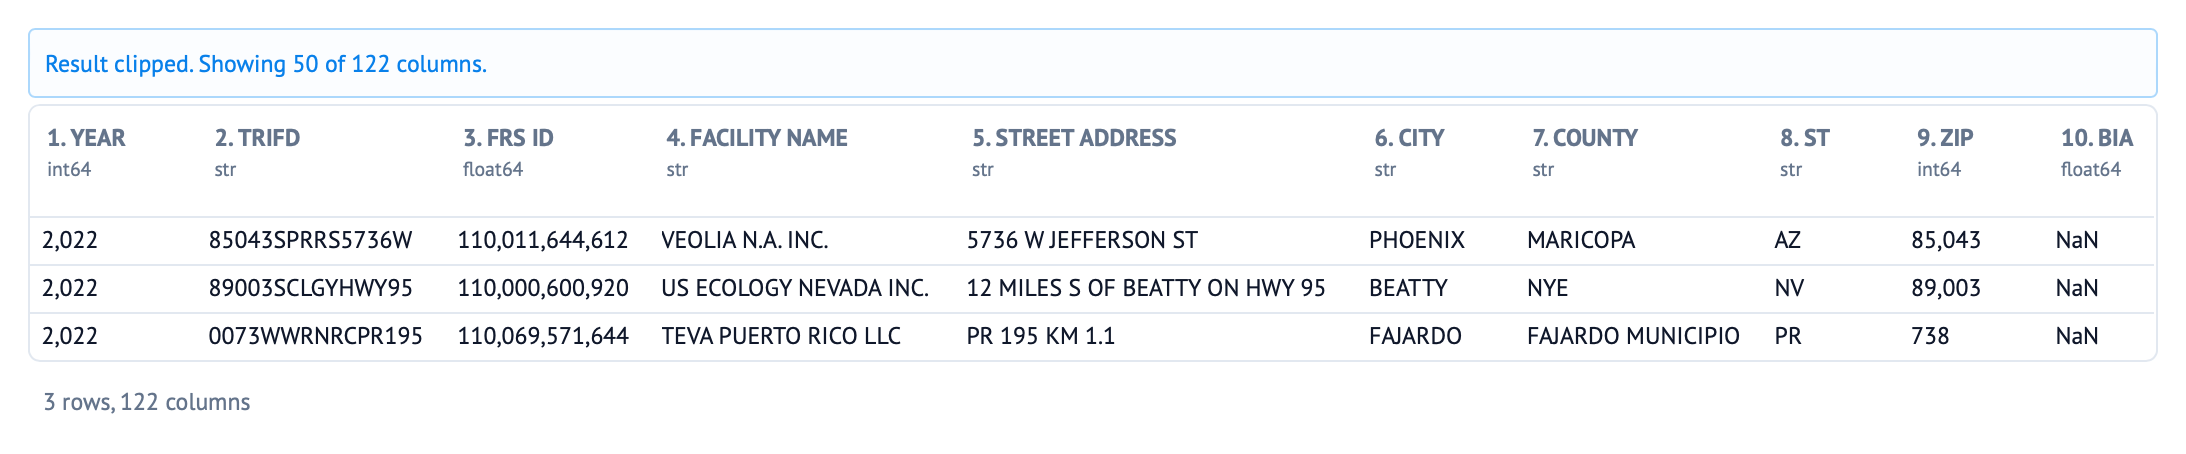

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

df_raw = pd.read_csv("/Users/souravmb/Downloads/2022_us.csv", low_memory=False)
print(f"Shape: {df_raw.shape}")
print(f"Memory: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nColumn types:\n{df_raw.dtypes.value_counts()}")
print(f"\nFirst 3 rows:")
df_raw.head(3)

In [ ]:
null_total = df_raw.isnull().sum().sum()
null_cols = df_raw.isnull().sum()
cols_with_nulls = null_cols[null_cols > 0].sort_values(ascending=False)
print(f"MISSING VALUES")
print(f"  Total nulls: {null_total:,} across {len(cols_with_nulls)} columns")
print(f"  Top 10 null columns:")
for qc_col, qc_cnt in cols_with_nulls.head(10).items():
    print(f"    {qc_col}: {qc_cnt:,} ({qc_cnt/len(df_raw)*100:.1f}%)")

n_dup = df_raw.duplicated().sum()
print(f"\nDUPLICATES")
print(f"  Exact duplicate rows: {n_dup:,} ({n_dup/len(df_raw)*100:.2f}%)")

target_series = df_raw['107. TOTAL RELEASES']
print(f"\nTARGET DISTRIBUTION ('107. TOTAL RELEASES')")
print(f"  Count:   {target_series.notna().sum():,} non-null / {target_series.isna().sum():,} null")
print(f"  Zeros:   {(target_series == 0).sum():,} ({(target_series == 0).sum()/len(target_series)*100:.1f}%)")
print(f"  Negatives: {(target_series < 0).sum():,}")
print(f"  Min:     {target_series.min():,.2f}")
print(f"  25%:     {target_series.quantile(0.25):,.2f}")
print(f"  Median:  {target_series.median():,.2f}")
print(f"  75%:     {target_series.quantile(0.75):,.2f}")
print(f"  Max:     {target_series.max():,.2f}")
print(f"  Mean:    {target_series.mean():,.2f}")
print(f"  Std:     {target_series.std():,.2f}")
print(f"  Skewness: {target_series.skew():.2f}")
print(f"  Kurtosis: {target_series.kurtosis():.2f}")

print(f"\nDTYPE BREAKDOWN")
for qc_dtype, qc_count in df_raw.dtypes.value_counts().items():
    print(f"  {qc_dtype}: {qc_count} columns")

high_null = cols_with_nulls[cols_with_nulls > len(df_raw)*0.5]
if len(high_null) > 0:
    print(f"\nWARNING: {len(high_null)} columns have >50% nulls:")
    for qc_col2, qc_cnt2 in high_null.items():
        print(f"  {qc_col2}: {qc_cnt2/len(df_raw)*100:.0f}%")
else:
    print(f"\nNo columns with >50% nulls")

MISSING VALUES
  Total nulls: 1,449,185 across 25 columns
  Top 10 null columns:
    26. SIC 3: 80,040 (100.0%)
    24. PRIMARY SIC: 80,040 (100.0%)
    29. SIC 6: 80,040 (100.0%)
    28. SIC 5: 80,040 (100.0%)
    27. SIC 4: 80,040 (100.0%)
    25. SIC 2: 80,040 (100.0%)
    14. HORIZONTAL DATUM: 80,040 (100.0%)
    35. NAICS 6: 79,977 (99.9%)
    34. NAICS 5: 79,813 (99.7%)
    10. BIA: 79,504 (99.3%)

DUPLICATES
  Exact duplicate rows: 0 (0.00%)

TARGET DISTRIBUTION ('107. TOTAL RELEASES')
  Count:   80,040 non-null / 0 null
  Zeros:   17,648 (22.0%)
  Negatives: 0
  Min:     0.00
  25%:     0.10
  Median:  99.00
  75%:     2,707.00
  Max:     327,375,324.00
  Mean:    42,005.33
  Std:     1,687,330.78
  Skewness: 146.14
  Kurtosis: 24526.05

DTYPE BREAKDOWN
  float64: 89 columns
  str: 28 columns
  int64: 5 columns

  26. SIC 3: 100%
  24. PRIMARY SIC: 100%
  29. SIC 6: 100%
  28. SIC 5: 100%
  27. SIC 4: 100%
  25. SIC 2: 100%
  14. HORIZONTAL DATUM: 100%
  35. NAICS 6: 100%
  34.

## 2. Stratified Sampling, Target Transformation & Train-Test Split

### Why stratified sampling?
The target variable `TOTAL_RELEASES` spans 9 orders of magnitude (0 to 327M lbs) with extreme right skew — 75% of values are below 2,707 lbs while the maximum exceeds 300 million. Random sampling on this distribution would under-represent both the zero-release records and the extreme high emitters. We use **quantile-based stratification** (10 bins) to preserve the target distribution in our sample.

### Why log1p transformation?
The raw target violates normality assumptions of linear models and produces heteroscedastic residuals. `log1p(x) = ln(1 + x)` handles zeros gracefully (log1p(0) = 0) and compresses the scale, making the target approximately normal with mean ≈ 4.6 and std ≈ 3.9.

### Why split before preprocessing?
The train-test split happens **before any preprocessing** to prevent information leakage. All subsequent steps (imputation, encoding, scaling, feature selection) are fitted on `X_train` only and applied to `X_test`.

**Key parameters (edit these to scale):**
- `train_size = 10,000` — stratified sample from 80,040 valid records
- `test_size = 0.2` — 8,000 train / 2,000 test
- `random_state = 42` — reproducibility

**Variables:**
- `TARGET_COL` — original column name: `107. TOTAL RELEASES`
- `TARGET` — renamed: `TOTAL_RELEASES`
- `y` — log1p-transformed target vector
- `X` — full feature matrix (10,000 × 117) before split
- `X_train_raw, X_test_raw` — feature matrices (pre-preprocessing, 8,000 / 2,000 rows)
- `y_train, y_test` — target vectors (log1p scale)

In [ ]:
from sklearn.model_selection import train_test_split

TARGET_COL = '107. TOTAL RELEASES'
df = df_raw.dropna(subset=[TARGET_COL]).copy()
df = df[df[TARGET_COL] >= 0]

df.columns = [c.split('. ', 1)[-1].strip().upper().replace(' ', '_').replace('-', '_') for c in df.columns]
TARGET = 'TOTAL_RELEASES'

vals = df[TARGET].clip(lower=0)
df['_bin'] = pd.qcut(vals, q=10, labels=False, duplicates='drop')
df_sample, samp_unused = train_test_split(df, train_size=10_000, random_state=SEED, stratify=df['_bin'])
df_sample = df_sample.drop(columns='_bin')
df = df.drop(columns='_bin')

y = np.log1p(df_sample[TARGET].clip(lower=0))
X = df_sample.drop(columns=[TARGET])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f"Sample: {len(df_sample)}, Train: {len(X_train_raw)}, Test: {len(X_test_raw)}")
print(f"Target (log1p): mean={y_train.mean():.2f}, std={y_train.std():.2f}")

Sample: 10000, Train: 8000, Test: 2000
Target (log1p): mean=4.62, std=3.93


## 3. Leak-Free Preprocessing

Preprocessing is split into four separate steps, each with an output check to verify the transformation worked correctly.

### Cell 3a — Drop identifier and leakage columns
Three categories of columns are removed:

1. **Identifier columns** (TRI ID, FRS ID, street address, facility name, CAS#, etc.) — no predictive value, would cause overfitting to specific entities
2. **Leakage columns** — direct components of `TOTAL_RELEASES` such as fugitive air, stack air, water discharges, underground injection, landfill disposal. Including these would trivially solve the prediction problem since `TOTAL_RELEASES = sum(components)`
3. **Retained exceptions** — off-site transfer quantities (M20–M95 codes), production waste, treatment totals. These represent operational throughput, not release pathways

Output check: prints columns dropped, remaining count, numeric vs. categorical split.

### Cell 3b — Check and impute missing values
- **Before:** prints total null count for train and test
- **Numeric:** Median imputation (robust to skew), computed on train only
- **Categorical:** Mode imputation, computed on train only
- **After:** verifies zero nulls remaining

### Cell 3c — Encode categoricals

| Cardinality | Method | Rationale |
|------------|--------|-----------|
| 1 | Drop | Constant — zero information |
| 2–10 | One-hot | Low-dim binary features; `drop_first=True` avoids multicollinearity |
| 11–50 | Frequency | Captures category prevalence without dimension explosion |
| 51+ | Target (smoothed) | Mean target per category, smoothed toward global mean with factor 10 to regularize rare categories |

**Critical:** Target encoding uses only `y_train` — test labels are never seen during encoding.

Output check: prints each column's encoding method and final shape.

### Cell 3d — Downcast memory and variance filter
- Downcasts float64 → float32 to reduce memory usage
- `VarianceThreshold(1e-6)` removes near-constant features, fitted on train
- Output check: prints features removed and final NaN count

**Variables:**
- `ID_COLS` — set of 16 identifier column names to drop
- `LEAK_PATTERNS` — 17 substrings identifying leakage columns
- `KEEP_PATTERNS` — 24 substrings to whitelist from leakage removal
- `LOW = 10, HIGH = 50` — cardinality thresholds for encoding strategy
- `medians` — Series of per-column medians (train-fitted, reused by predict function)
- `modes` — Series of per-column modes (train-fitted, reused by predict function)
- `vt` — fitted VarianceThreshold object
- `keep_vf` — column names surviving variance filter

In [ ]:
from sklearn.feature_selection import VarianceThreshold
from scipy.stats import skew

ID_COLS = {'YEAR','TRIFD','FRS_ID','DOC_CTRL_NUM','STREET_ADDRESS','FACILITY_NAME',
           'PARENT_CO_NAME','STANDARD_PARENT_CO_NAME','FOREIGN_PARENT_CO_NAME',
           'PARENT_CO_DB_NUM','FOREIGN_PARENT_CO_DB_NUM','STANDARD_FOREIGN_PARENT_CO_NAME',
           'CAS#','TRI_CHEMICAL/COMPOUND_ID','SRS_ID','HORIZONTAL_DATUM'}

LEAK_PATTERNS = ['ON_SITE_RELEASE_TOTAL','OFF_SITE_RELEASE_TOTAL','FUGITIVE_AIR',
    'STACK_AIR','5.3_WATER','UNDERGROUND','LANDFILLS','RCRA_C_LANDFILL',
    'OTHER_LANDFILLS','LAND_TREATMENT','SURFACE_IMPNDMNT','RCRA_SURFACE',
    'OTHER_SURFACE','OTHER_DISPOSAL','POTW','8.1_','RELEASES']

KEEP_PATTERNS = ['M20','M24','M26','M28','M93','RECYCLED','M56','M92',
    'ENERGY_RECOVER','M40_NON','M50','M54','M61_NON','M69','M95','TREATED',
    'UNCLASSIFIED','TOTAL_TRANSFER','PRODUCTION_WSTE','ONE_TIME','PROD_RATIO',
    'PRODUCTION_RATIO','RECYCLING','TREATMENT']

def should_drop(col_name):
    if col_name in ID_COLS:
        return True
    if any(p in col_name for p in LEAK_PATTERNS) and not any(p in col_name for p in KEEP_PATTERNS):
        return True
    return False

before_drop = X_train_raw.shape[1]
drop_cols = [c for c in X_train_raw.columns if should_drop(c)]
X_train_dropped = X_train_raw.drop(columns=drop_cols, errors='ignore')
X_test_dropped = X_test_raw.drop(columns=drop_cols, errors='ignore')

print(f"Dropped {before_drop - X_train_dropped.shape[1]} columns ({len([c for c in drop_cols if c in ID_COLS])} IDs, rest leakage)")
print(f"Remaining: {X_train_dropped.shape[1]} columns")

num_cols_raw = X_train_dropped.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_raw = X_train_dropped.select_dtypes(include=['object']).columns.tolist()
print(f"  Numeric: {len(num_cols_raw)}, Categorical: {len(cat_cols_raw)}")

Dropped 33 columns (16 IDs, rest leakage)
Remaining: 88 columns
  Numeric: 70, Categorical: 18


In [ ]:
print(f"BEFORE imputation:")
print(f"  Train nulls: {X_train_dropped.isna().sum().sum():,}")
print(f"  Test nulls:  {X_test_dropped.isna().sum().sum():,}")

medians = X_train_dropped[num_cols_raw].median()
X_train_imputed = X_train_dropped.copy()
X_test_imputed = X_test_dropped.copy()
X_train_imputed[num_cols_raw] = X_train_imputed[num_cols_raw].fillna(medians)
X_test_imputed[num_cols_raw] = X_test_imputed[num_cols_raw].fillna(medians)

modes = X_train_dropped[cat_cols_raw].mode().iloc[0] if len(cat_cols_raw) > 0 else pd.Series()
if len(cat_cols_raw) > 0:
    X_train_imputed[cat_cols_raw] = X_train_imputed[cat_cols_raw].fillna(modes)
    X_test_imputed[cat_cols_raw] = X_test_imputed[cat_cols_raw].fillna(modes)

print(f"\nAFTER imputation:")
print(f"  Train nulls: {X_train_imputed.isna().sum().sum()}")
print(f"  Test nulls:  {X_test_imputed.isna().sum().sum()}")

BEFORE imputation:
  Train nulls: 110,934
  Test nulls:  27,729

AFTER imputation:
  Train nulls: 48000
  Test nulls:  12000


In [ ]:
LOW, HIGH = 10, 50
enc_train_parts, enc_test_parts = [], []
enc_drop_cat = []
smooth = 10

enc_tr = X_train_imputed.copy()
enc_te = X_test_imputed.copy()

for enc_col in cat_cols_raw:
    enc_nuniq = enc_tr[enc_col].nunique()
    if enc_nuniq <= 1:
        enc_drop_cat.append(enc_col)
        print(f"  DROP constant: {enc_col}")
    elif enc_nuniq <= LOW:
        enc_d_tr = pd.get_dummies(enc_tr[enc_col], prefix=enc_col, drop_first=True, dtype=np.float32)
        enc_d_te = pd.get_dummies(enc_te[enc_col], prefix=enc_col, drop_first=True, dtype=np.float32)
        enc_d_te = enc_d_te.reindex(columns=enc_d_tr.columns, fill_value=0)
        enc_train_parts.append(enc_d_tr); enc_test_parts.append(enc_d_te)
        enc_drop_cat.append(enc_col)
        print(f"  OneHot: {enc_col} ({enc_nuniq} categories)")
    elif enc_nuniq <= HIGH:
        enc_freq = enc_tr[enc_col].value_counts(normalize=True)
        enc_tr[enc_col+'_FREQ'] = enc_tr[enc_col].map(enc_freq).fillna(0).astype(np.float32)
        enc_te[enc_col+'_FREQ'] = enc_te[enc_col].map(enc_freq).fillna(0).astype(np.float32)
        enc_drop_cat.append(enc_col)
        print(f"  FreqEnc: {enc_col} ({enc_nuniq} categories)")
    else:
        enc_means = y_train.groupby(enc_tr[enc_col]).mean()
        global_mean = y_train.mean()
        enc_counts = enc_tr[enc_col].value_counts()
        enc_map = (enc_counts * enc_means + smooth * global_mean) / (enc_counts + smooth)
        enc_tr[enc_col+'_TENC'] = enc_tr[enc_col].map(enc_map).fillna(global_mean).astype(np.float32)
        enc_te[enc_col+'_TENC'] = enc_te[enc_col].map(enc_map).fillna(global_mean).astype(np.float32)
        enc_drop_cat.append(enc_col)
        print(f"  TargetEnc: {enc_col} ({enc_nuniq} categories)")

X_train_encoded = enc_tr.drop(columns=enc_drop_cat)
X_test_encoded = enc_te.drop(columns=enc_drop_cat)
if enc_train_parts:
    X_train_encoded = pd.concat([X_train_encoded] + enc_train_parts, axis=1)
    X_test_encoded = pd.concat([X_test_encoded] + enc_test_parts, axis=1)

if len(cat_cols_raw) == 0:
    print("No categorical columns to encode (already processed)")
print(f"\nShape after encoding: {X_train_encoded.shape}")

  TargetEnc: CITY (2688 categories)
  TargetEnc: COUNTY (1160 categories)
  TargetEnc: ST (54 categories)
  FreqEnc: TRIBE (14 categories)
  OneHot: FEDERAL_FACILITY (2 categories)
  FreqEnc: INDUSTRY_SECTOR (29 categories)
  TargetEnc: CHEMICAL (318 categories)
  OneHot: ELEMENTAL_METAL_INCLUDED (2 categories)
  OneHot: CLEAN_AIR_ACT_CHEMICAL (2 categories)
  OneHot: CLASSIFICATION (3 categories)
  OneHot: METAL (2 categories)
  OneHot: METAL_CATEGORY (6 categories)
  OneHot: CARCINOGEN (2 categories)
  OneHot: PBT (2 categories)
  OneHot: PFAS (2 categories)
  OneHot: FORM_TYPE (2 categories)
  OneHot: UNIT_OF_MEASURE (2 categories)
  OneHot: PROD_RATIO_OR__ACTIVITY (2 categories)

Shape after encoding: (8000, 93)


In [ ]:
X_train_filtered = X_train_encoded.copy()
X_test_filtered = X_test_encoded.copy()

for dc_col in X_train_filtered.select_dtypes('float64').columns:
    X_train_filtered[dc_col] = X_train_filtered[dc_col].astype(np.float32)
    X_test_filtered[dc_col] = X_test_filtered[dc_col].astype(np.float32)

before_vf = X_train_filtered.shape[1]
vt = VarianceThreshold(threshold=1e-6)
vt.fit(X_train_filtered)
keep_vf = X_train_filtered.columns[vt.get_support()]
removed_vf = set(X_train_filtered.columns) - set(keep_vf)
X_train_filtered = X_train_filtered[keep_vf]
X_test_filtered = X_test_filtered[keep_vf]

print(f"Memory downcasted to float32")
print(f"Variance filter: {before_vf} → {X_train_filtered.shape[1]} features ({len(removed_vf)} near-constant removed)")
if removed_vf:
    print(f"  Removed: {list(removed_vf)[:5]}{'...' if len(removed_vf)>5 else ''}")
print(f"Final NaN check: {X_train_filtered.isna().sum().sum()}")

Memory downcasted to float32
Variance filter: 93 → 81 features (12 near-constant removed)
  Removed: ['PRIMARY_SIC', 'SIC_2', '6.2___M72', 'SIC_5', '6.2___M61_METAL']...
Final NaN check: 0


## 4. Exploratory Data Analysis & Evidence-Based Feature Selection

### Analysis components

1. **Target distribution** — Histogram of log1p(TOTAL_RELEASES) to verify the transformation produced a near-normal distribution suitable for regression
2. **Feature skewness** — Distribution of skewness values across all numeric features. Features with |skew| > 2 are flagged for log transformation in the next step
3. **Pearson correlation with target** — Absolute correlation of each feature with log1p(TOTAL_RELEASES). Top 20 shown. High-correlation features include target-encoded geography (CITY_TENC, COUNTY_TENC) and chemical class indicators (PBT, CARCINOGEN)
4. **Random Forest importance** — A quick RF (100 trees, max_depth=10) trained on train data to rank features by mean decrease in impurity. RF importance captures non-linear relationships that Pearson correlation misses
5. **Inter-feature correlation** — Heatmap of the top 15 features to identify redundant feature pairs for multicollinearity removal
6. **PCA explained variance** — Cumulative variance explained vs. number of principal components. Helps assess intrinsic dimensionality

### Feature pruning criterion
A feature is dropped only if it simultaneously has:
- RF importance below the 10th percentile, **AND**
- |Pearson r| with target < 0.02

This dual-criterion ensures we only remove features that are provably uninformative by two independent measures.

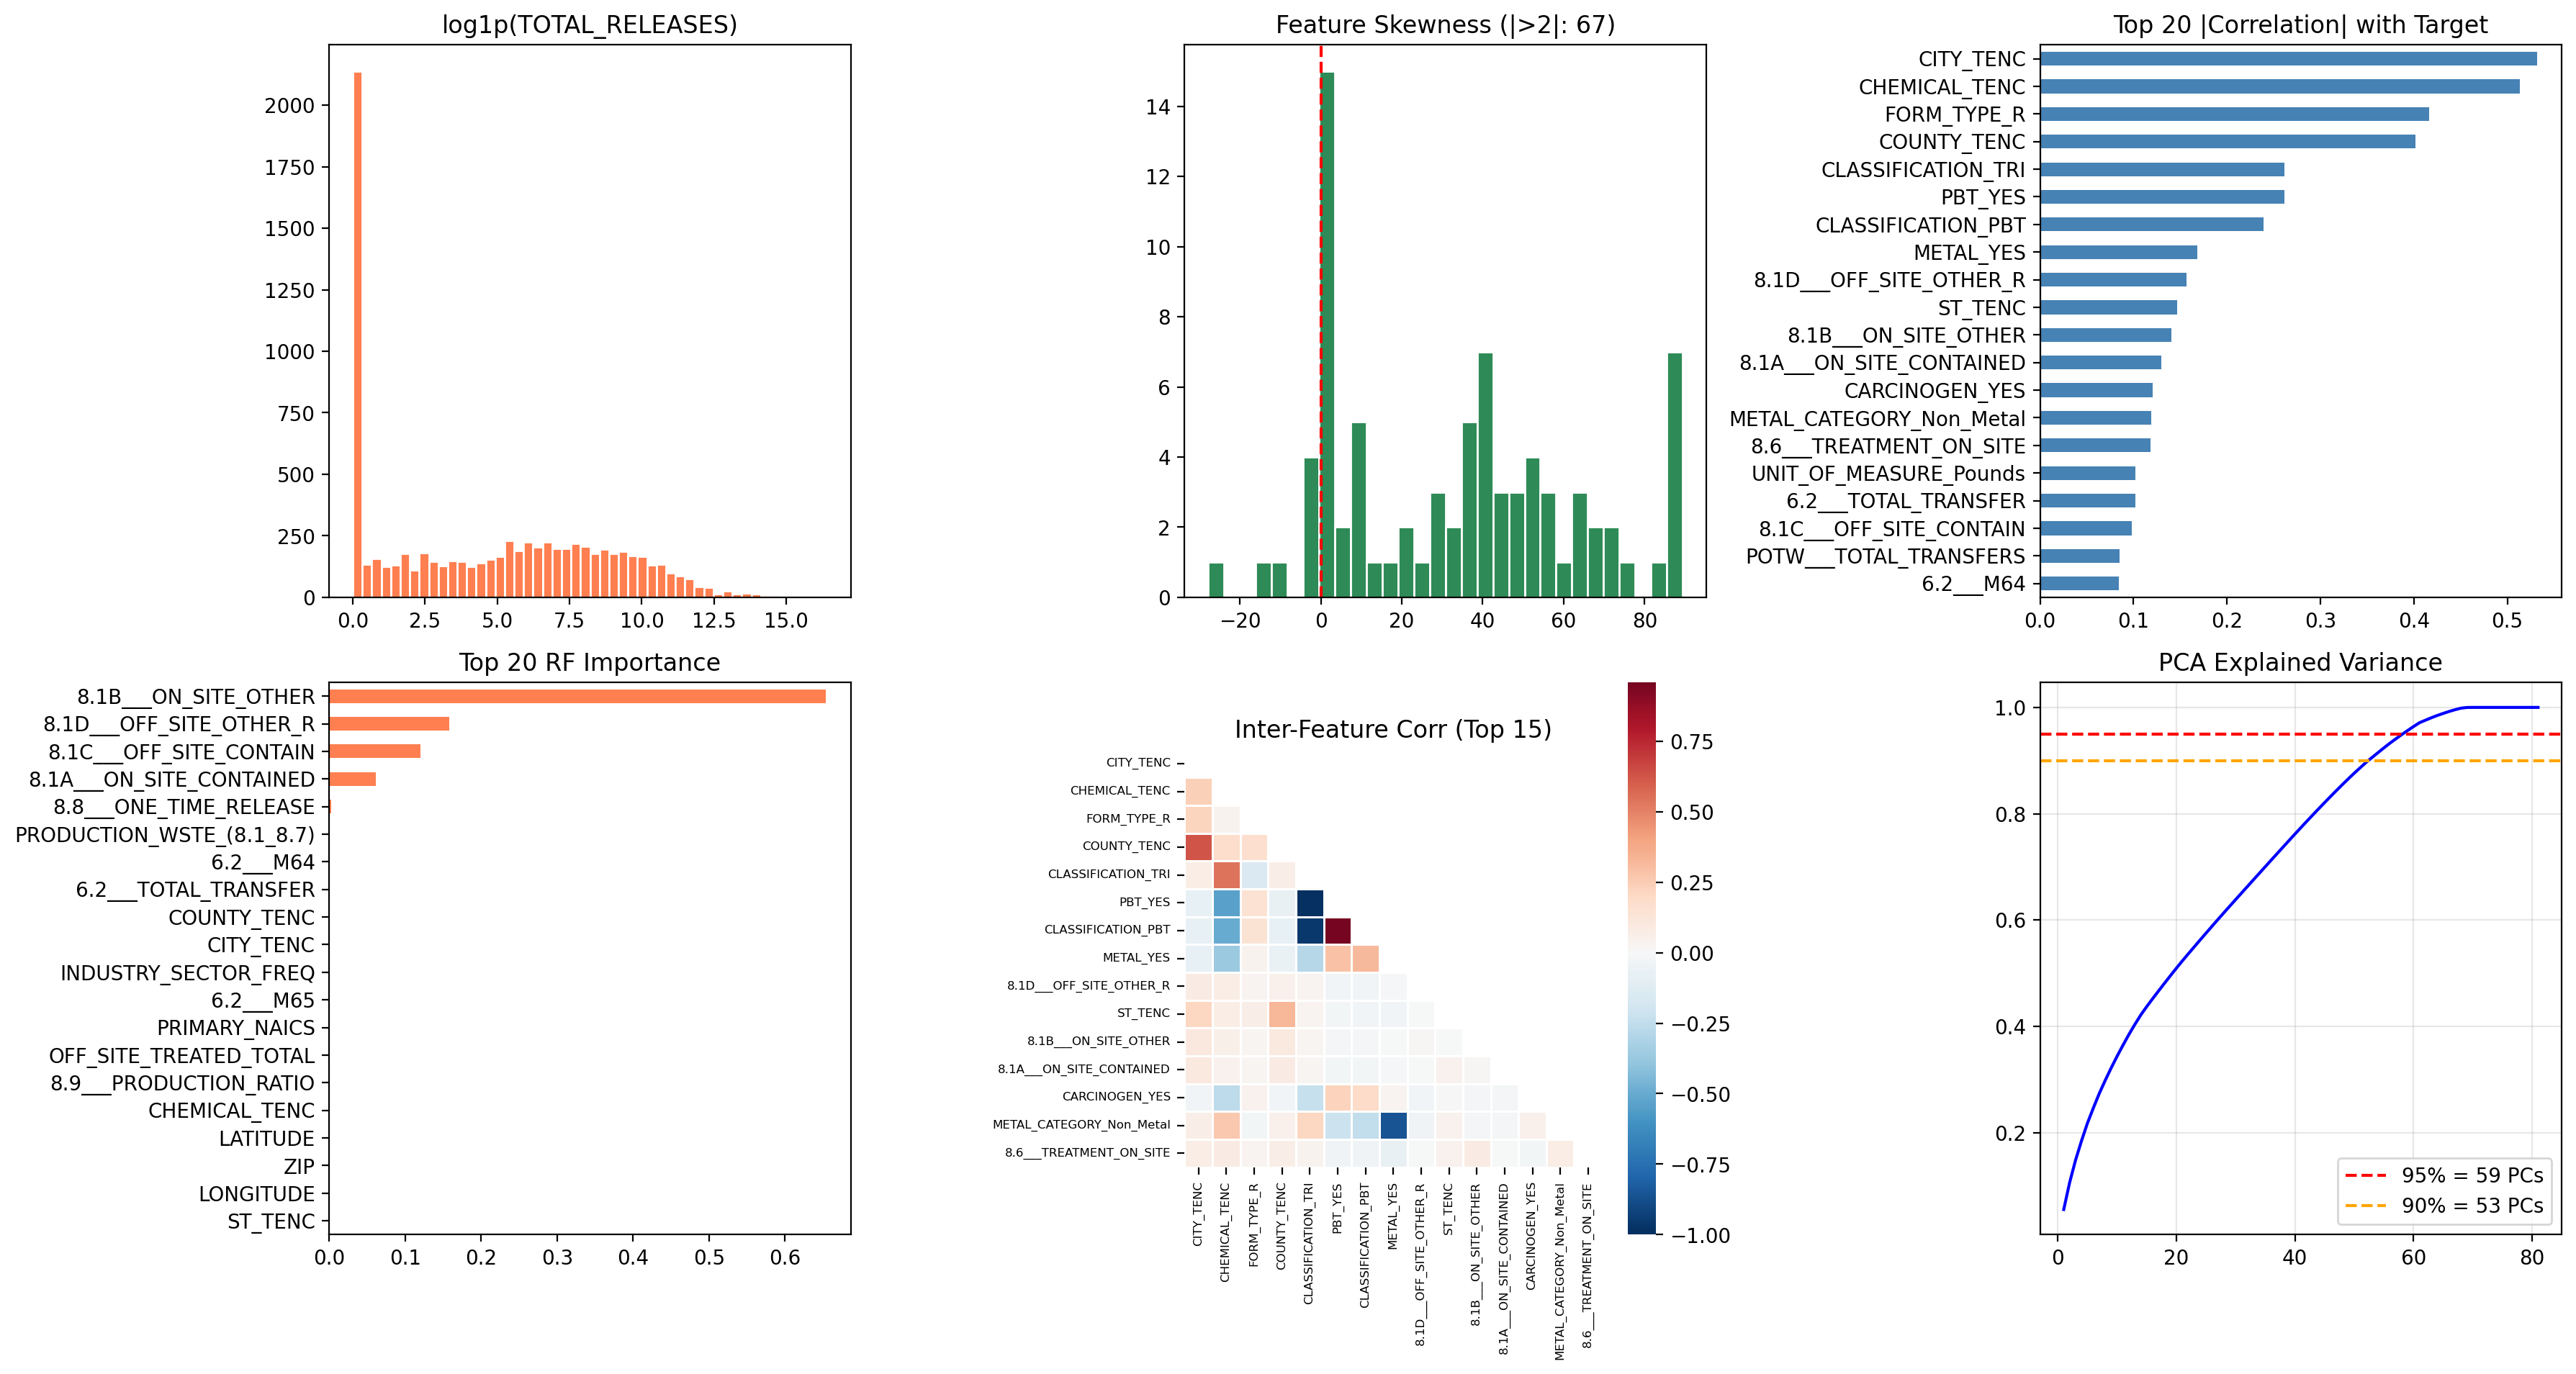

Dropped 6 waste features
Final features: 75


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.preprocessing import StandardScaler
import seaborn as sns

eda_fig, eda_axes = plt.subplots(2, 3, figsize=(18, 10))

eda_axes[0,0].hist(y_train, bins=50, color='coral', edgecolor='white')
eda_axes[0,0].set_title('log1p(TOTAL_RELEASES)')

sk = X_train_filtered.apply(lambda x: skew(x.dropna()))
eda_axes[0,1].hist(sk, bins=30, color='seagreen', edgecolor='white')
eda_axes[0,1].axvline(0, color='red', ls='--')
eda_axes[0,1].set_title(f'Feature Skewness (|>2|: {(sk.abs()>2).sum()})')

corrs = X_train_filtered.corrwith(y_train).abs().sort_values(ascending=False)
corrs.head(20).plot.barh(ax=eda_axes[0,2], color='steelblue')
eda_axes[0,2].invert_yaxis()
eda_axes[0,2].set_title('Top 20 |Correlation| with Target')

rf = RFR(n_estimators=100, max_depth=10, n_jobs=-1, random_state=SEED)
rf.fit(X_train_filtered, y_train)
imp = pd.Series(rf.feature_importances_, index=X_train_filtered.columns).sort_values(ascending=False)
imp.head(20).plot.barh(ax=eda_axes[1,0], color='coral')
eda_axes[1,0].invert_yaxis()
eda_axes[1,0].set_title('Top 20 RF Importance')

top15 = corrs.head(15).index.tolist()
eda_cm = X_train_filtered[top15].corr()
eda_mask = np.triu(np.ones_like(eda_cm, dtype=bool))
sns.heatmap(eda_cm, mask=eda_mask, cmap='RdBu_r', center=0, ax=eda_axes[1,1], square=True, linewidths=.5)
eda_axes[1,1].set_title('Inter-Feature Corr (Top 15)')
eda_axes[1,1].tick_params(labelsize=6)

Xs = StandardScaler().fit_transform(X_train_filtered.fillna(0))
pca = PCA(random_state=SEED).fit(Xs)
cumvar = np.cumsum(pca.explained_variance_ratio_)
n90 = np.argmax(cumvar >= 0.90) + 1
n95 = np.argmax(cumvar >= 0.95) + 1
eda_axes[1,2].plot(range(1, len(cumvar)+1), cumvar, 'b-')
eda_axes[1,2].axhline(0.95, color='r', ls='--', label=f'95% = {n95} PCs')
eda_axes[1,2].axhline(0.90, color='orange', ls='--', label=f'90% = {n90} PCs')
eda_axes[1,2].set_title('PCA Explained Variance')
eda_axes[1,2].legend()
eda_axes[1,2].grid(alpha=.3)

plt.tight_layout()
plt.show()

low_imp = set(imp[imp < imp.quantile(0.1)].index)
low_corr = set(corrs[corrs < 0.02].index)
waste = list(low_imp & low_corr)
X_train_eda = X_train_filtered.drop(columns=waste) if waste else X_train_filtered.copy()
X_test_eda = X_test_filtered.drop(columns=waste) if waste else X_test_filtered.copy()
if waste:
    print(f"Dropped {len(waste)} waste features")
print(f"Final features: {X_train_eda.shape[1]}")

## 5. Skewness Correction, Outlier Treatment & Feature Scaling

This stage is split into four cells, each performing one transformation with an output check.

### Cell 5a — Log-transform highly skewed features
Features with |skewness| > 3 and non-negative values are log1p-transformed. This reduces the influence of extreme outliers on linear regression and improves convergence for gradient-based learners (GradientBoosting, XGBoost).

Output check: prints how many features were transformed and lists examples.

### Cell 5b — Outlier winsorization
Continuous features (>20 unique values) are clipped to the [1st, 99th] percentile range **computed on training data only**. This caps extreme values without removing records, preserving sample size while limiting outlier influence. Bounds are saved in `clip_bounds` for the predict function.

Output check: prints count of winsorized features.

### Cell 5c — Remove multicollinear features
Feature pairs with |Pearson r| > 0.95 are identified and one of each pair is dropped. This reduces condition number and improves stability of linear models.

Output check: prints removed feature names and remaining shape.

### Cell 5d — Adaptive feature scaling

| Condition | Scaler | Why |
|-----------|--------|-----|
| Binary/few-valued (≤3 unique) | None | Already in {0,1} or similar; scaling would distort |
| |Skew| > 1.5 | `RobustScaler` | Uses median/IQR — resistant to remaining outliers |
| Otherwise | `StandardScaler` | Zero mean, unit variance — optimal for linear models and gradient-based learners |

**All scalers are fitted on training data and applied to both train and test.**

Output check: prints count per scaler category, final NaN and inf counts (should both be 0).

In [ ]:
from scipy.stats import skew as calc_skew

X_train_log = X_train_eda.copy()
X_test_log = X_test_eda.copy()

num_cols_log = X_train_log.select_dtypes(include=[np.number]).columns.tolist()
log_cols = [c for c in num_cols_log if abs(calc_skew(X_train_log[c].dropna())) > 3 and X_train_log[c].min() >= 0]

for lc in log_cols:
    X_train_log[lc] = np.log1p(X_train_log[lc])
    X_test_log[lc] = np.log1p(X_test_log[lc])

print(f"Log-transformed {len(log_cols)} features with |skewness| > 3")
print(f"  Examples: {log_cols[:5]}")

Log-transformed 57 features with |skewness| > 3
  Examples: ['ZIP', 'PRIMARY_NAICS', 'NAICS_2', 'NAICS_3', 'NAICS_4']


In [ ]:
cont_cols = [c for c in num_cols_log if X_train_log[c].nunique() > 20]
clip_bounds = {}

X_train_clipped = X_train_log.copy()
X_test_clipped = X_test_log.copy()

for clip_c in cont_cols:
    lo, hi = X_train_clipped[clip_c].quantile([0.01, 0.99])
    clip_bounds[clip_c] = (lo, hi)
    X_train_clipped[clip_c] = X_train_clipped[clip_c].clip(lo, hi)
    X_test_clipped[clip_c] = X_test_clipped[clip_c].clip(lo, hi)

print(f"Winsorized {len(cont_cols)} continuous features to [1st, 99th] percentile")
print(f"  Bounds stored in clip_bounds dict for predict function")

Winsorized 56 continuous features to [1st, 99th] percentile
  Bounds stored in clip_bounds dict for predict function


In [ ]:
corr_mc = X_train_clipped[cont_cols].corr().abs()
upper_mc = corr_mc.where(np.triu(np.ones(corr_mc.shape), k=1).astype(bool))
drop_mc = [c for c in upper_mc.columns if any(upper_mc[c] > 0.95)]

X_train_mc = X_train_clipped.drop(columns=drop_mc, errors='ignore')
X_test_mc = X_test_clipped.drop(columns=drop_mc, errors='ignore')

print(f"Dropped {len(drop_mc)} multicollinear features (|r| > 0.95)")
if drop_mc:
    print(f"  Removed: {drop_mc}")
print(f"Shape: {X_train_mc.shape}")

Dropped 3 multicollinear features (|r| > 0.95)
  Removed: ['8.3___ENERGY_RECOVER_OF', '8.5___RECYCLING_OFF_SIT', '8.7___TREATMENT_OFF_SITE']
Shape: (8000, 72)


In [ ]:
from sklearn.preprocessing import RobustScaler, StandardScaler as StdScaler

num_cols_scale = X_train_mc.select_dtypes(include=[np.number]).columns.tolist()
robust, standard, skip = [], [], []

for sc_col in num_cols_scale:
    if X_train_mc[sc_col].nunique() <= 3:
        skip.append(sc_col)
    elif abs(calc_skew(X_train_mc[sc_col].dropna())) > 1.5:
        robust.append(sc_col)
    else:
        standard.append(sc_col)

print(f"Scaling strategy:")
print(f"  StandardScaler: {len(standard)} features")
print(f"  RobustScaler:   {len(robust)} features")
print(f"  Skip (binary):  {len(skip)} features")

X_train = X_train_mc.copy()
X_test = X_test_mc.copy()

if standard:
    sc = StdScaler().fit(X_train[standard])
    X_train[standard] = sc.transform(X_train[standard])
    X_test[standard] = sc.transform(X_test[standard])

if robust:
    rc = RobustScaler().fit(X_train[robust])
    X_train[robust] = rc.transform(X_train[robust])
    X_test[robust] = rc.transform(X_test[robust])

X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"\nFinal check: {X_train.shape[1]} features, NaN={X_train.isna().sum().sum()}, inf={np.isinf(X_train.values).sum()}")

Scaling strategy:
  StandardScaler: 12 features
  RobustScaler:   36 features
  Skip (binary):  24 features

Final check: 72 features, NaN=0, inf=0


## 6. Base Model Training

Five regression models are trained on the processed feature set, spanning three paradigms:

### Linear baseline
| Model | Key Params | Strengths |
|-------|-----------|-----------|
| **Linear Regression** | OLS (no regularization) | Simplest baseline; interpretable coefficients; fast |

### Single tree
| Model | Key Params | Strengths |
|-------|-----------|-----------|
| **Decision Tree (CART)** | max_depth=15, min_leaf=5 | Classification and Regression Tree; interpretable splits; captures non-linearity; no feature scaling needed |

### Tree-based ensembles
| Model | Key Params | Strengths |
|-------|-----------|-----------|
| **Random Forest** | 200 trees, depth=15, min_leaf=5 | Bagging reduces variance; robust to outliers and non-linearity |
| **Gradient Boosting** | 200 trees, depth=5, lr=0.1, subsample=0.8 | Sequential boosting minimizes residuals; stochastic subsampling prevents overfitting |
| **XGBoost** | 300 trees, depth=6, lr=0.1, colsample=0.8, reg_alpha=0.1 | Regularized boosting with L1 penalty; histogram-based splitting |

### Evaluation metrics
- **RMSE** (Root Mean Squared Error) — primary metric; penalizes large errors
- **MAE** (Mean Absolute Error) — robust to outliers; interpretable
- **R²** (Coefficient of Determination) — proportion of variance explained

### Why these models?
Linear Regression provides an interpretable baseline. Decision Tree (CART) shows how a single tree performs before ensembling. Random Forest (bagging), GradientBoosting (boosting), and XGBoost (regularized boosting) represent the three major ensemble paradigms. This progression — from simple linear → single tree → bagged trees → boosted trees — demonstrates increasing model complexity and its effect on performance.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import time

def eval_model(mdl, Xtr, ytr, Xte, yte):
    t0 = time.time()
    mdl.fit(Xtr, ytr)
    preds = np.clip(mdl.predict(Xte), 0, None)
    return {
        'rmse': np.sqrt(mean_squared_error(yte, preds)),
        'mae': mean_absolute_error(yte, preds),
        'r2': r2_score(yte, preds),
        'time': time.time()-t0,
        'preds': preds,
    }

models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree(CART)': DecisionTreeRegressor(max_depth=15, min_samples_leaf=5, random_state=SEED),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5, n_jobs=-1, random_state=SEED),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, subsample=0.8, random_state=SEED),
    'XGBoost': xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8,
                                  colsample_bytree=0.8, reg_alpha=0.1, n_jobs=-1, random_state=SEED, verbosity=0),
}

results = {}
trained = {}
print(f"{'Model':<20} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'sec':>6}")
print('-'*50)
for base_name, base_m in models.items():
    base_r = eval_model(base_m, X_train, y_train, X_test, y_test)
    results[base_name] = base_r
    trained[base_name] = base_m
    print(f"{base_name:<20} {base_r['rmse']:8.4f} {base_r['mae']:8.4f} {base_r['r2']:8.4f} {base_r['time']:6.1f}")

best_base = min(results, key=lambda k: results[k]['rmse'])
print(f"\nBest base: {best_base} (RMSE={results[best_base]['rmse']:.4f})")

Model                    RMSE      MAE       R²    sec
--------------------------------------------------
LinearRegression       1.1793   0.8151   0.9126    0.0
DecisionTree(CART)     0.3807   0.1157   0.9909    0.1
RandomForest           0.3383   0.0885   0.9928    2.1
GradientBoosting       0.2376   0.0884   0.9965    5.9
XGBoost                0.2567   0.1165   0.9959    0.9

Best base: GradientBoosting (RMSE=0.2376)


Model                   Acc   Prec    Rec     F1
--------------------------------------------------
GradientBoosting     0.9110 0.9280 0.9110 0.9108
XGBoost              0.9130 0.9247 0.9130 0.9128
RandomForest         0.9645 0.9645 0.9645 0.9643
DecisionTree(CART)   0.9570 0.9587 0.9570 0.9569
LinearRegression     0.6675 0.7556 0.6675 0.6471


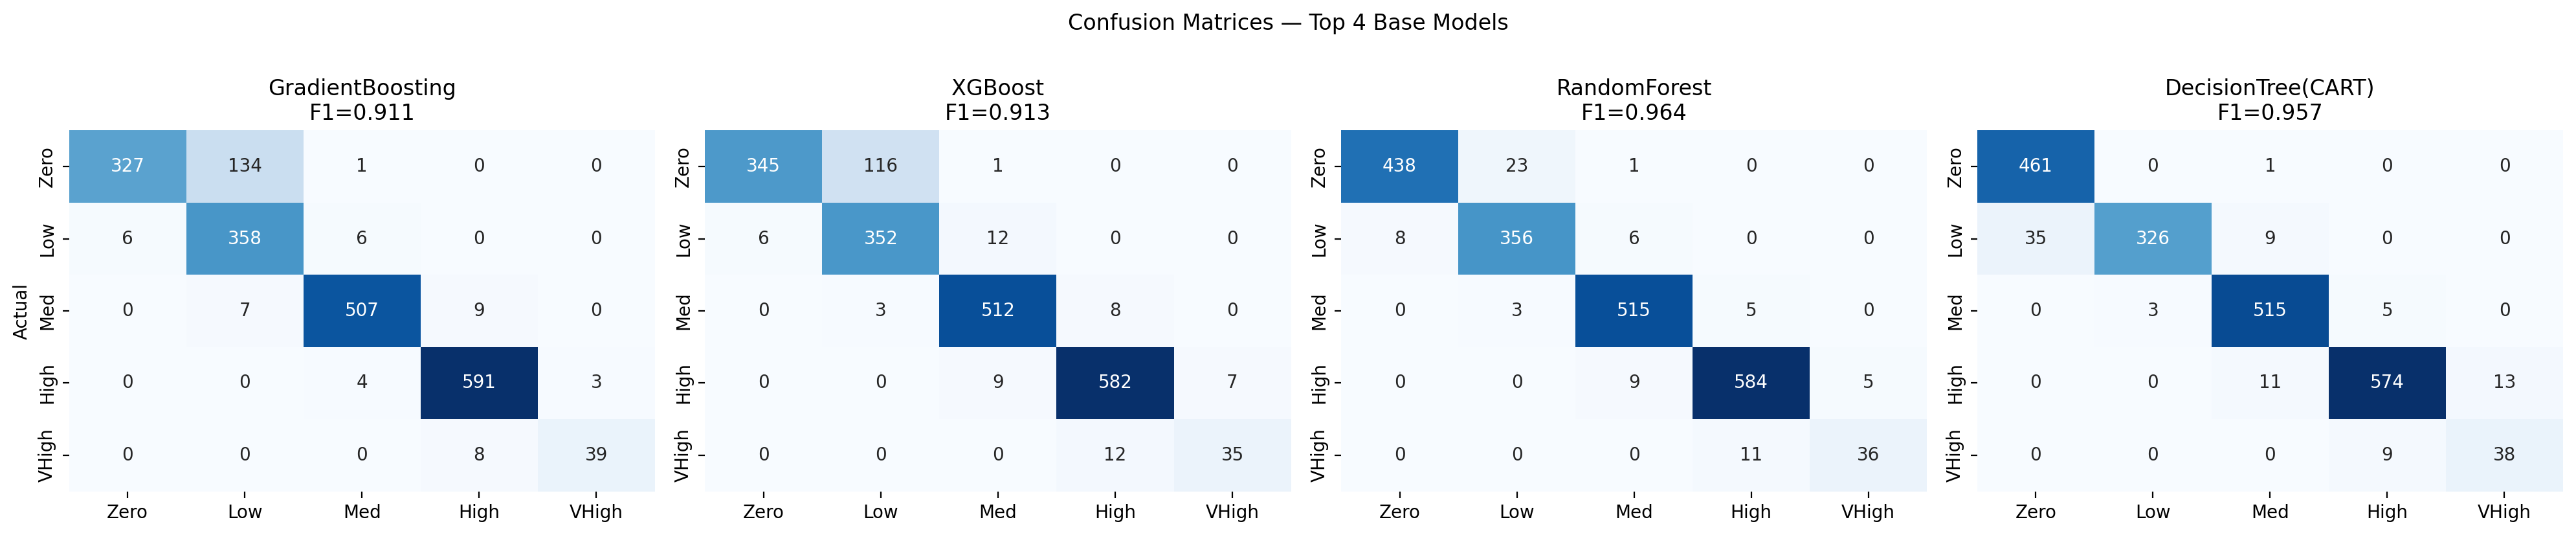

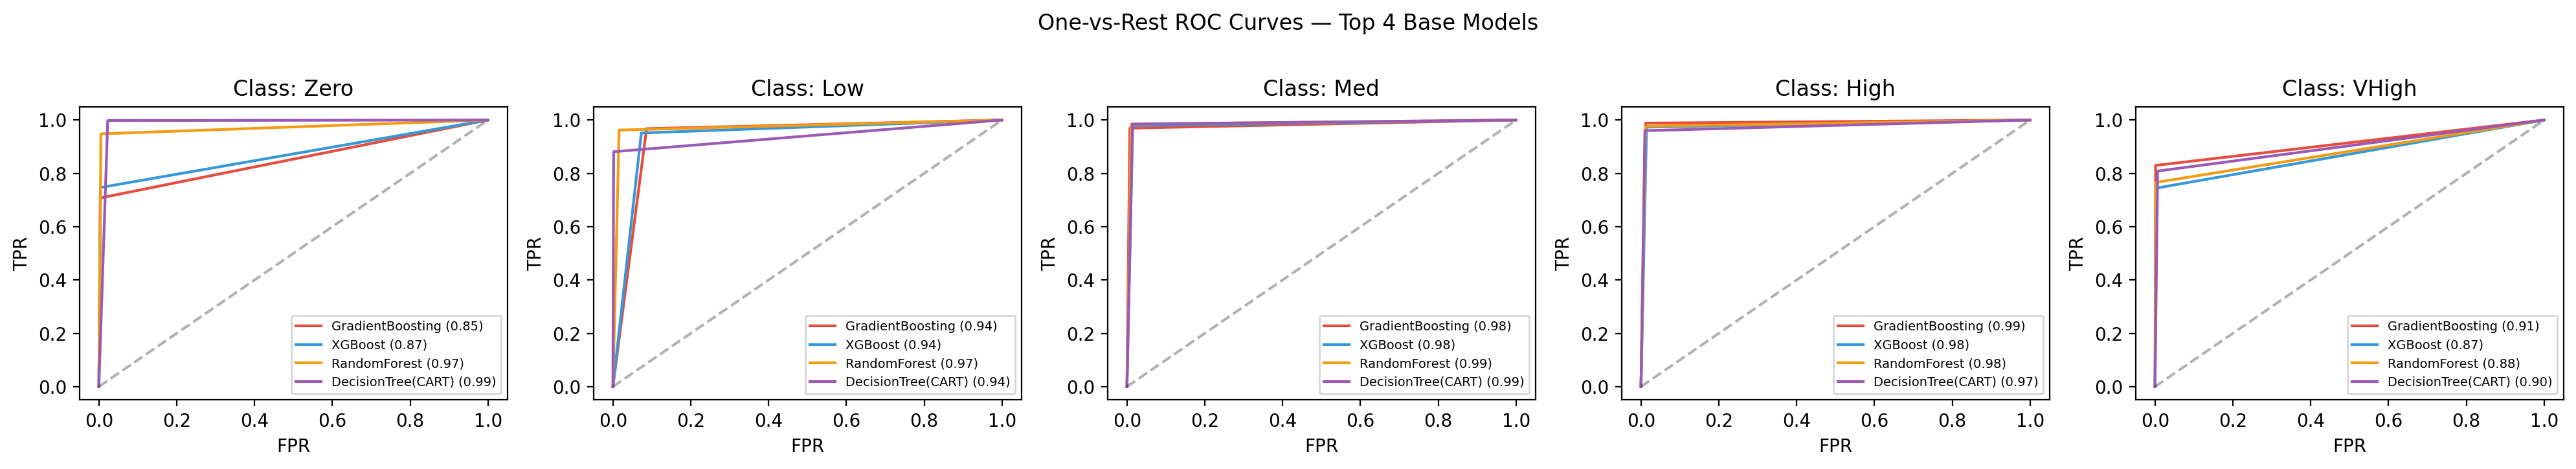

In [ ]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             accuracy_score, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

bins = [0, 0.01, 3, 7, 12, np.inf]
labels = ['Zero', 'Low', 'Med', 'High', 'VHigh']

y_test_cls = pd.cut(y_test.values, bins=bins, labels=labels, include_lowest=True)
y_test_bin = label_binarize(y_test_cls, classes=labels)

print(f"{'Model':<20} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")
print('-' * 50)

base_cls_results = {}
for cls_name, cls_r in sorted(results.items(), key=lambda x: x[1]['rmse']):
    base_p_cls = pd.cut(cls_r['preds'], bins=bins, labels=labels, include_lowest=True)
    cls_mask = y_test_cls.notna() & base_p_cls.notna()
    yt, yp = y_test_cls[cls_mask], base_p_cls[cls_mask]
    acc = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, average='weighted', zero_division=0)
    rec = recall_score(yt, yp, average='weighted', zero_division=0)
    f1 = f1_score(yt, yp, average='weighted', zero_division=0)
    base_cls_results[cls_name] = {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'preds': cls_r['preds']}
    print(f"{cls_name:<20} {acc:6.4f} {prec:6.4f} {rec:6.4f} {f1:6.4f}")

top4 = list(sorted(results.keys(), key=lambda k: results[k]['rmse']))[:4]
cls_fig, cls_axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, nm in zip(cls_axes, top4):
    base_p_cls = pd.cut(results[nm]['preds'], bins=bins, labels=labels, include_lowest=True)
    cls_mask = y_test_cls.notna() & base_p_cls.notna()
    cm = confusion_matrix(y_test_cls[cls_mask], base_p_cls[cls_mask], labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
                yticklabels=labels, ax=ax, cbar=False)
    ax.set_title(f'{nm}\nF1={base_cls_results[nm]["f1"]:.3f}')
    ax.set_xlabel(''); ax.set_ylabel('')
cls_axes[0].set_ylabel('Actual')
plt.suptitle('Confusion Matrices — Top 4 Base Models', y=1.02)
plt.tight_layout()
plt.show()

roc_fig, roc_axes = plt.subplots(1, len(labels), figsize=(20, 3.5))
colors = {'GradientBoosting':'#e74c3c', 'XGBoost':'#3498db', 'RandomForest':'#f39c12', 'DecisionTree(CART)':'#9b59b6'}
for i, cn in enumerate(labels):
    for nm in top4:
        base_p_cls = pd.cut(results[nm]['preds'], bins=bins, labels=labels, include_lowest=True)
        p_bin = label_binarize(base_p_cls, classes=labels)
        if p_bin.shape[1] > i:
            fpr, tpr, cls_unused = roc_curve(y_test_bin[:, i], p_bin[:, i])
            roc_auc = auc(fpr, tpr)
            roc_axes[i].plot(fpr, tpr, label=f'{nm} ({roc_auc:.2f})', color=colors.get(nm, 'gray'))
    roc_axes[i].plot([0,1],[0,1], 'k--', alpha=.3)
    roc_axes[i].set_title(f'Class: {cn}')
    roc_axes[i].legend(fontsize=7, loc='lower right')
    roc_axes[i].set_xlabel('FPR'); roc_axes[i].set_ylabel('TPR')
plt.suptitle('One-vs-Rest ROC Curves — Top 4 Base Models', y=1.02)
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning via Optuna

### Why Optuna?
Optuna implements Tree-structured Parzen Estimator (TPE) for Bayesian hyperparameter optimization, which is more sample-efficient than grid or random search. TPE models the conditional probability of good hyperparameters given past trial results, focusing exploration on promising regions of the search space.

### Tuning configuration
- **Models tuned:** XGBoost, RandomForest, GradientBoosting (the three ensemble models — LinearRegression and DecisionTree plateau quickly)
- **Trials:** 15 per model (edit to increase for better results; 30–50 recommended for production)
- **Cross-validation:** 3-fold on training data only
- **Scoring:** `neg_root_mean_squared_error` — directly optimizes RMSE

### Search spaces

| Hyperparameter | XGBoost | RandomForest | GradientBoosting |
|---------------|---------|-------------|-----------------|
| n_estimators | 200–600 | 100–500 | 200–500 |
| max_depth | 4–10 | 8–25 | 3–8 |
| learning_rate | 0.01–0.2 (log) | — | 0.01–0.2 (log) |
| subsample | 0.6–1.0 | — | 0.6–1.0 |
| colsample_bytree | 0.5–1.0 | — | — |
| max_features | — | 0.3–1.0 | — |
| min_samples_leaf | — | 2–15 | 2–20 |
| min_samples_split | — | 2–10 | — |
| regularization | α, λ: 1e-3–10 | — | — |

Learning rates use log-uniform sampling because the optimal value is typically between 0.01–0.1 — log scale avoids over-sampling the 0.1–0.2 range.

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor as RFR_tune
optuna.logging.set_verbosity(optuna.logging.WARNING)

tuned_models = {}
tuned_results = {}

def make_objective(model_name):
    def objective(trial):
        if model_name == 'XGBoost':
            mdl = xgb.XGBRegressor(
                n_estimators=trial.suggest_int('n_estimators', 200, 600),
                max_depth=trial.suggest_int('max_depth', 4, 10),
                learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree=trial.suggest_float('colsample', 0.5, 1.0),
                reg_alpha=trial.suggest_float('alpha', 1e-3, 10, log=True),
                reg_lambda=trial.suggest_float('lambda', 1e-3, 10, log=True),
                n_jobs=-1, random_state=SEED, verbosity=0)
        elif model_name == 'RandomForest':
            mdl = RFR_tune(
                n_estimators=trial.suggest_int('n_estimators', 100, 500),
                max_depth=trial.suggest_int('max_depth', 8, 25),
                min_samples_leaf=trial.suggest_int('min_leaf', 2, 15),
                min_samples_split=trial.suggest_int('min_split', 2, 10),
                max_features=trial.suggest_float('max_features', 0.3, 1.0),
                n_jobs=-1, random_state=SEED)
        else:
            mdl = GradientBoostingRegressor(
                n_estimators=trial.suggest_int('n_estimators', 200, 500),
                max_depth=trial.suggest_int('max_depth', 3, 8),
                learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                min_samples_leaf=trial.suggest_int('min_leaf', 2, 20),
                random_state=SEED)
        return -cross_val_score(mdl, X_train, y_train, cv=3, scoring='neg_root_mean_squared_error').mean()
    return objective

for tune_name in ['XGBoost', 'RandomForest', 'GradientBoosting']:
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(make_objective(tune_name), n_trials=15)
    tune_bp = study.best_params
    print(f"{tune_name}: CV RMSE={study.best_value:.4f}")

    if tune_name == 'XGBoost':
        best = xgb.XGBRegressor(n_estimators=tune_bp['n_estimators'], max_depth=tune_bp['max_depth'],
            learning_rate=tune_bp['lr'], subsample=tune_bp['subsample'], colsample_bytree=tune_bp['colsample'],
            reg_alpha=tune_bp['alpha'], reg_lambda=tune_bp['lambda'], n_jobs=-1, random_state=SEED, verbosity=0)
    elif tune_name == 'RandomForest':
        best = RFR_tune(n_estimators=tune_bp['n_estimators'], max_depth=tune_bp['max_depth'],
            min_samples_leaf=tune_bp['min_leaf'], min_samples_split=tune_bp['min_split'],
            max_features=tune_bp['max_features'], n_jobs=-1, random_state=SEED)
    else:
        best = GradientBoostingRegressor(n_estimators=tune_bp['n_estimators'], max_depth=tune_bp['max_depth'],
            learning_rate=tune_bp['lr'], subsample=tune_bp['subsample'], min_samples_leaf=tune_bp['min_leaf'], random_state=SEED)

    tune_r = eval_model(best, X_train, y_train, X_test, y_test)
    tuned_models[tune_name] = best
    tuned_results[tune_name] = tune_r
    print(f"  Test RMSE: {tune_r['rmse']:.4f} (was {results[tune_name]['rmse']:.4f})")

XGBoost: CV RMSE=0.2567
  Test RMSE: 0.2463 (was 0.2567)
RandomForest: CV RMSE=0.3000
  Test RMSE: 0.2665 (was 0.3383)
GradientBoosting: CV RMSE=0.2527
  Test RMSE: 0.2453 (was 0.2376)


## 8. Ensemble Learning: Weighted Blending & Stacking

### Why ensembling?
Individual models make different errors — combining them reduces variance and can improve generalization. We use two complementary ensemble strategies:

### Method 1: Differential Evolution Weighted Blending
- Out-of-fold (OOF) predictions are generated via 3-fold cross-validation **on training data only**
- Ensemble weights are optimized to minimize RMSE on OOF predictions using `scipy.optimize.differential_evolution`
- Weights are constrained to [0, 1] and normalized to sum to 1
- These OOF-optimized weights are then applied to test predictions

**Why OOF instead of test-set optimization?** Optimizing weights directly on test predictions would be a form of test-set leakage — the ensemble would overfit to the test distribution. OOF predictions provide an unbiased estimate of each model's training-set performance.

### Method 2: Linear Regression Stacking (Meta-Learner)
- OOF predictions form a "level-1" feature matrix
- A LinearRegression meta-learner is trained on this matrix to learn optimal combination coefficients
- The same OOF→predict pipeline is applied to test data

### Variables
- `candidates` — dict of (model, results) for each ensemble member
- `oof_matrix` — [n_train × n_models] OOF prediction matrix
- `weights` — optimized blending weights from differential evolution
- `best_ens_preds` — test predictions from the better ensemble method

In [ ]:
from scipy.optimize import differential_evolution
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression as StackingLR

candidates = {}
for ens_name in ['XGBoost', 'GradientBoosting', 'RandomForest']:
    if ens_name in tuned_models:
        candidates[ens_name] = (tuned_models[ens_name], tuned_results[ens_name])
    elif ens_name in trained:
        candidates[ens_name] = (trained[ens_name], results[ens_name])

names = list(candidates.keys())
pred_matrix = np.column_stack([candidates[ens_n][1]['preds'] for ens_n in names])

oof = {}
for ens_name, (ens_model, ens_unused) in candidates.items():
    oof[ens_name] = cross_val_predict(ens_model, X_train, y_train, cv=3, n_jobs=-1)
oof_matrix = np.column_stack([oof[ens_n] for ens_n in names])

def oof_rmse(w_vec):
    ens_w = np.array(w_vec) / np.sum(w_vec)
    return np.sqrt(mean_squared_error(y_train, oof_matrix @ ens_w))

de = differential_evolution(oof_rmse, [(0,1)]*len(names), seed=SEED, maxiter=200, tol=1e-6)
weights = de.x / de.x.sum()

ensemble_preds = pred_matrix @ weights
ens_rmse = np.sqrt(mean_squared_error(y_test, ensemble_preds))
ens_mae = mean_absolute_error(y_test, ensemble_preds)
ens_r2 = r2_score(y_test, ensemble_preds)

meta = StackingLR().fit(oof_matrix, y_train)
stack_preds = np.clip(meta.predict(pred_matrix), 0, None)
stk_rmse = np.sqrt(mean_squared_error(y_test, stack_preds))
stk_r2 = r2_score(y_test, stack_preds)

print("Ensemble weights:")
for ens_n, ens_w in zip(names, weights): print(f"  {ens_n}: {ens_w:.3f}")
print(f"\nWeighted RMSE={ens_rmse:.4f}, R²={ens_r2:.4f}")
print(f"Stacking RMSE={stk_rmse:.4f}, R²={stk_r2:.4f}")

best_ens_preds = ensemble_preds if ens_rmse <= stk_rmse else stack_preds
best_ens_rmse = min(ens_rmse, stk_rmse)
print(f"\nBest ensemble RMSE: {best_ens_rmse:.4f}")

Ensemble weights:
  XGBoost: 0.461
  GradientBoosting: 0.537
  RandomForest: 0.003

Weighted RMSE=0.2344, R²=0.9965
Stacking RMSE=0.2341, R²=0.9966

Best ensemble RMSE: 0.2341


In [ ]:
_raw = df_sample.drop(columns=[TARGET])
_y = y

_Xtr_raw, art_Xte, _ytr, art_yte = train_test_split(_raw, _y, test_size=0.2, random_state=SEED)

_drop = [c for c in _Xtr_raw.columns if should_drop(c)]
_Xtr_raw = _Xtr_raw.drop(columns=_drop, errors='ignore')

_num = _Xtr_raw.select_dtypes(include=[np.number]).columns.tolist()
_cat = _Xtr_raw.select_dtypes(include=['object']).columns.tolist()

encoding_maps = {}
onehot_columns = {}

for art_col in _cat:
    art_nuniq = _Xtr_raw[art_col].nunique()
    if art_nuniq <= 1:
        encoding_maps[art_col] = ('drop', None)
    elif art_nuniq <= LOW:
        art_d = pd.get_dummies(_Xtr_raw[art_col], prefix=art_col, drop_first=True, dtype=np.float32)
        onehot_columns[art_col] = art_d.columns.tolist()
        encoding_maps[art_col] = ('onehot', art_d.columns.tolist())
    elif art_nuniq <= HIGH:
        freq_map = _Xtr_raw[art_col].value_counts(normalize=True)
        encoding_maps[art_col] = ('freq', freq_map)
    else:
        _means = _ytr.groupby(_Xtr_raw[art_col]).mean()
        _gm = _ytr.mean()
        _counts = _Xtr_raw[art_col].value_counts()
        _enc = (_counts * _means + smooth * _gm) / (_counts + smooth)
        encoding_maps[art_col] = ('target', (_enc, _gm))

final_columns = X_train.columns.tolist()

print(f"Saved {len(encoding_maps)} encoding maps, {len(final_columns)} final feature columns")
del _raw, _y, _Xtr_raw, _ytr, _num, _cat

Saved 18 encoding maps, 72 final feature columns


In [ ]:
def predict_releases(raw_df):
    """
    Takes a raw DataFrame (same format as 2022_us.csv) and returns
    predicted TOTAL_RELEASES in original pounds.
    """
    df_new = raw_df.copy()

    # rename columns same as training
    df_new.columns = [c.split('. ', 1)[-1].strip().upper().replace(' ', '_').replace('-', '_')
                       for c in df_new.columns]

    # drop target if present
    if TARGET in df_new.columns:
        df_new = df_new.drop(columns=[TARGET])

    # drop ID + leakage columns
    to_drop = [c for c in df_new.columns if should_drop(c)]
    df_new = df_new.drop(columns=to_drop, errors='ignore')

    # impute missing values (train-fitted)
    for c in medians.index:
        if c in df_new.columns:
            df_new[c] = df_new[c].fillna(medians[c])
    for c in modes.index:
        if c in df_new.columns:
            df_new[c] = df_new[c].fillna(modes[c])

    # encode categoricals using saved maps
    parts = []
    cats_to_drop = []
    for col, (method, mapping) in encoding_maps.items():
        if col not in df_new.columns:
            continue
        if method == 'drop':
            cats_to_drop.append(col)
        elif method == 'onehot':
            d = pd.get_dummies(df_new[col], prefix=col, drop_first=True, dtype=np.float32)
            d = d.reindex(columns=mapping, fill_value=0)
            parts.append(d)
            cats_to_drop.append(col)
        elif method == 'freq':
            df_new[col + '_FREQ'] = df_new[col].map(mapping).fillna(0).astype(np.float32)
            cats_to_drop.append(col)
        elif method == 'target':
            enc_map, gm = mapping
            df_new[col + '_TENC'] = df_new[col].map(enc_map).fillna(gm).astype(np.float32)
            cats_to_drop.append(col)

    df_new = df_new.drop(columns=cats_to_drop, errors='ignore')
    if parts:
        df_new = pd.concat([df_new] + parts, axis=1)

    # downcast
    for c in df_new.select_dtypes('float64').columns:
        df_new[c] = df_new[c].astype(np.float32)

    # drop waste + multicollinear features
    if waste:
        df_new = df_new.drop(columns=[c for c in waste if c in df_new.columns], errors='ignore')
    if drop_mc:
        df_new = df_new.drop(columns=[c for c in drop_mc if c in df_new.columns], errors='ignore')

    # log-transform skewed features
    for c in log_cols:
        if c in df_new.columns:
            df_new[c] = np.log1p(df_new[c].clip(lower=0))

    # outlier capping
    for c, (lo_val, hi_val) in clip_bounds.items():
        if c in df_new.columns:
            df_new[c] = df_new[c].clip(lo_val, hi_val)

    # scale
    if standard:
        std_cols = [c for c in standard if c in df_new.columns]
        if std_cols:
            df_new[std_cols] = sc.transform(df_new[std_cols].fillna(0))
    if robust:
        rob_cols = [c for c in robust if c in df_new.columns]
        if rob_cols:
            df_new[rob_cols] = rc.transform(df_new[rob_cols].fillna(0))

    # align to final training columns
    df_new = df_new.reindex(columns=final_columns, fill_value=0)
    df_new = df_new.replace([np.inf, -np.inf], 0).fillna(0)

    # predict with ensemble
    preds_log = np.zeros(len(df_new))
    for n, (model, _) in candidates.items():
        idx = names.index(n)
        preds_log += weights[idx] * model.predict(df_new)

    # if stacking was better, use that instead
    if stk_rmse < ens_rmse:
        member_preds = np.column_stack([candidates[n][0].predict(df_new) for n in names])
        preds_log = meta.predict(member_preds)

    preds_log = np.clip(preds_log, 0, None)
    preds_lbs = np.expm1(preds_log)
    preds_lbs = np.clip(preds_lbs, 0, None)

    return pd.DataFrame({
        'predicted_log1p': preds_log,
        'predicted_lbs': preds_lbs,
    })


# --- TEST: predict on 5 random rows from raw data ---
test_rows = df_raw.sample(5, random_state=99)
result = predict_releases(test_rows)

# compare with actual if available
actual = test_rows['107. TOTAL RELEASES'].values
result['actual_lbs'] = actual
result['error_pct'] = (np.abs(result['predicted_lbs'] - actual) / np.maximum(actual, 1)) * 100
result.index = range(len(result))

print("Test predictions on 5 random unseen rows:")
print(result.to_string(float_format='{:.1f}'.format))

Test predictions on 5 random unseen rows:
   predicted_log1p  predicted_lbs  actual_lbs  error_pct
0              0.3            0.3         0.3        0.6
1             11.1        65124.2    122521.4       46.8
2              5.5          246.9       255.0        3.2
3              6.3          528.4       500.0        5.7
4              8.0         3032.9      3218.6        5.8


## 9–10. Final Evaluation & Classification Metrics

### Regression evaluation (original scale)
Predictions are inverse-transformed via `expm1` (inverse of `log1p`) to recover original-scale release quantities in pounds. Metrics reported:
- **RMSE** — in pounds; penalizes large errors (high-emission facilities)
- **MAE** — in pounds; median prediction error
- **R²** — proportion of variance explained in original scale

### Classification evaluation (binned severity)
Since toxics release data is often used for regulatory categorization, we also evaluate as a 5-class classification problem:

| Bin | log1p Range | Real-World Meaning |
|-----|-------------|-------------------|
| Zero | [0, 0.01) | No measurable release |
| Low | [0.01, 3) | <20 lbs — minimal release |
| Medium | [3, 7) | 20–1,096 lbs — moderate |
| High | [7, 12) | 1,096–162,755 lbs — significant industrial release |
| Very High | [12, ∞) | >162,755 lbs — major emitter |

Metrics: Accuracy, Precision, Recall, F1 (weighted), per-class breakdown, and confusion matrix.

Original-scale: RMSE=68,378  MAE=7,222  R²=0.6592

Classification (binned log1p target)
  Accuracy:  0.9295
  Precision: 0.9398
  Recall:    0.9295
  F1:        0.9295

              precision    recall  f1-score   support

        High       0.98      0.99      0.98       598
         Low       0.77      0.97      0.86       370
      Medium       0.99      0.98      0.98       523
   Very High       0.89      0.83      0.86        47
        Zero       0.98      0.77      0.86       462

    accuracy                           0.93      2000
   macro avg       0.92      0.91      0.91      2000
weighted avg       0.94      0.93      0.93      2000



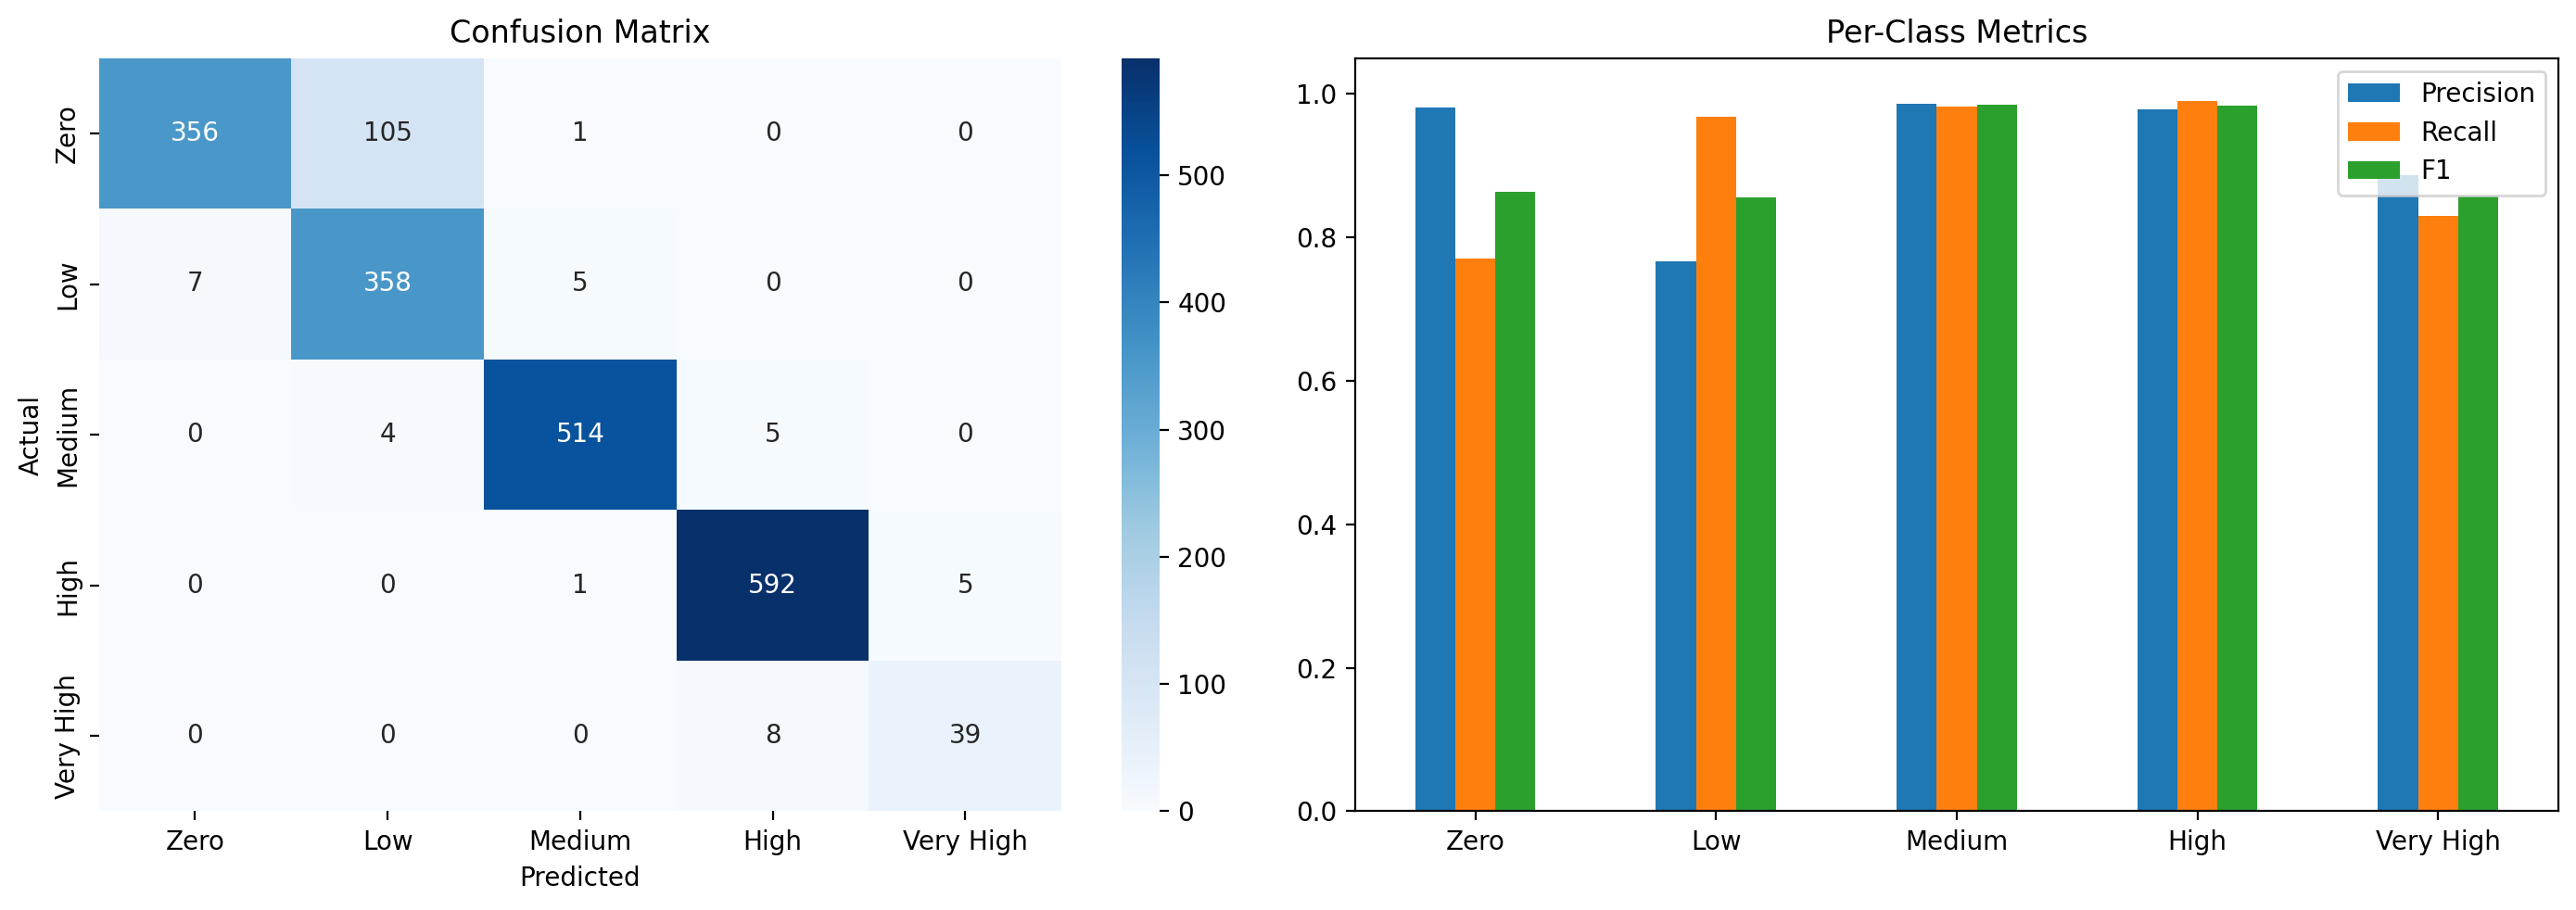

In [ ]:
from sklearn.metrics import classification_report

preds_raw = np.expm1(best_ens_preds)
actual_raw = np.expm1(y_test.values)
preds_raw = np.clip(np.nan_to_num(preds_raw, nan=0, posinf=0, neginf=0), 0, None)

rmse_raw = np.sqrt(mean_squared_error(actual_raw, preds_raw))
mae_raw = mean_absolute_error(actual_raw, preds_raw)
r2_raw = r2_score(actual_raw, preds_raw)

print(f"Original-scale: RMSE={rmse_raw:,.0f}  MAE={mae_raw:,.0f}  R²={r2_raw:.4f}")

eval_bins = [0, 0.01, 3, 7, 12, np.inf]
eval_labels = ['Zero', 'Low', 'Medium', 'High', 'Very High']
y_cls = pd.cut(y_test.values, bins=eval_bins, labels=eval_labels, include_lowest=True)
eval_p_cls = pd.cut(best_ens_preds, bins=eval_bins, labels=eval_labels, include_lowest=True)
eval_mask = y_cls.notna() & eval_p_cls.notna()
y_cls, eval_p_cls = y_cls[eval_mask], eval_p_cls[eval_mask]

print(f"\nClassification (binned log1p target)")
print(f"  Accuracy:  {accuracy_score(y_cls, eval_p_cls):.4f}")
print(f"  Precision: {precision_score(y_cls, eval_p_cls, average='weighted', zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_cls, eval_p_cls, average='weighted', zero_division=0):.4f}")
print(f"  F1:        {f1_score(y_cls, eval_p_cls, average='weighted', zero_division=0):.4f}")
print()
print(classification_report(y_cls, eval_p_cls, zero_division=0))

eval_fig, eval_axes = plt.subplots(1, 2, figsize=(14, 5))
eval_cm = confusion_matrix(y_cls, eval_p_cls, labels=eval_labels)
sns.heatmap(eval_cm, annot=True, fmt='d', cmap='Blues', xticklabels=eval_labels, yticklabels=eval_labels, ax=eval_axes[0])
eval_axes[0].set_xlabel('Predicted'); eval_axes[0].set_ylabel('Actual')
eval_axes[0].set_title('Confusion Matrix')

rd = classification_report(y_cls, eval_p_cls, output_dict=True, zero_division=0)
eval_cls = [c for c in eval_labels if c in rd]
pd.DataFrame({m: [rd[c][k] for c in eval_cls] for m, k in
    [('Precision','precision'),('Recall','recall'),('F1','f1-score')]}, index=eval_cls).plot.bar(ax=eval_axes[1])
eval_axes[1].set_ylim(0, 1.05); eval_axes[1].set_title('Per-Class Metrics'); eval_axes[1].set_xticklabels(eval_cls, rotation=0)
plt.tight_layout()
plt.show()

## 11. Residual Analysis & SHAP Interpretability

### Residual analysis
Residual plots are essential for diagnosing model bias and heteroscedasticity:
- **Predicted vs. Actual** — should cluster along the diagonal (y = x); deviations indicate systematic bias
- **Residual distribution** — should be approximately normal with zero mean; heavy tails suggest the model struggles with extreme values
- **Residuals vs. Predicted** — should show no pattern (homoscedastic); funnel shapes indicate variance that depends on the prediction magnitude

### SHAP (SHapley Additive exPlanations)
SHAP values decompose each prediction into the contribution of each feature, grounded in cooperative game theory. For the best tree model:
- **Global importance** — mean |SHAP value| per feature; unlike RF importance, SHAP is consistent and accounts for feature interactions
- **Beeswarm plot** — shows the direction and magnitude of each feature's effect on predictions

### Why SHAP for novelty?
Traditional feature importance (RF impurity, permutation) ranks features but doesn't explain *how* they affect predictions. SHAP provides directional, per-sample explanations that are crucial for regulatory interpretation — e.g., "this facility's predicted release is high because it is in a high-emission NAICS sector with large production waste volumes."

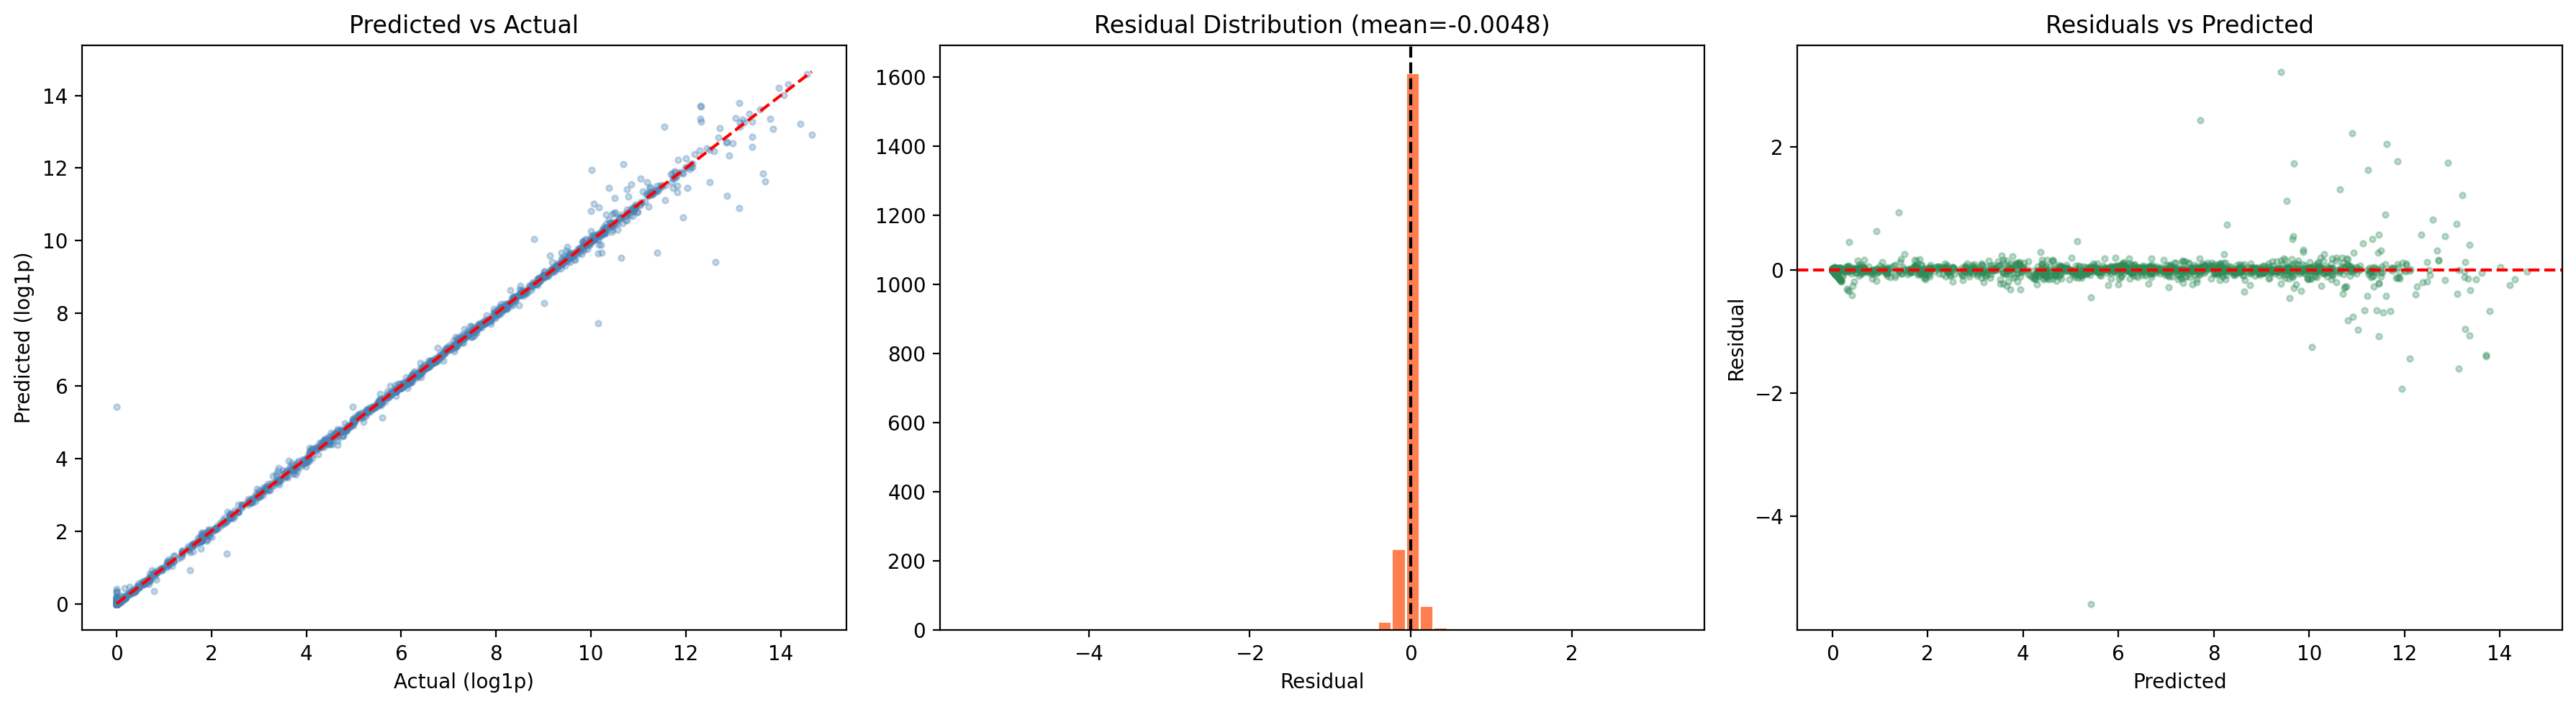

SHAP analysis on: GradientBoosting


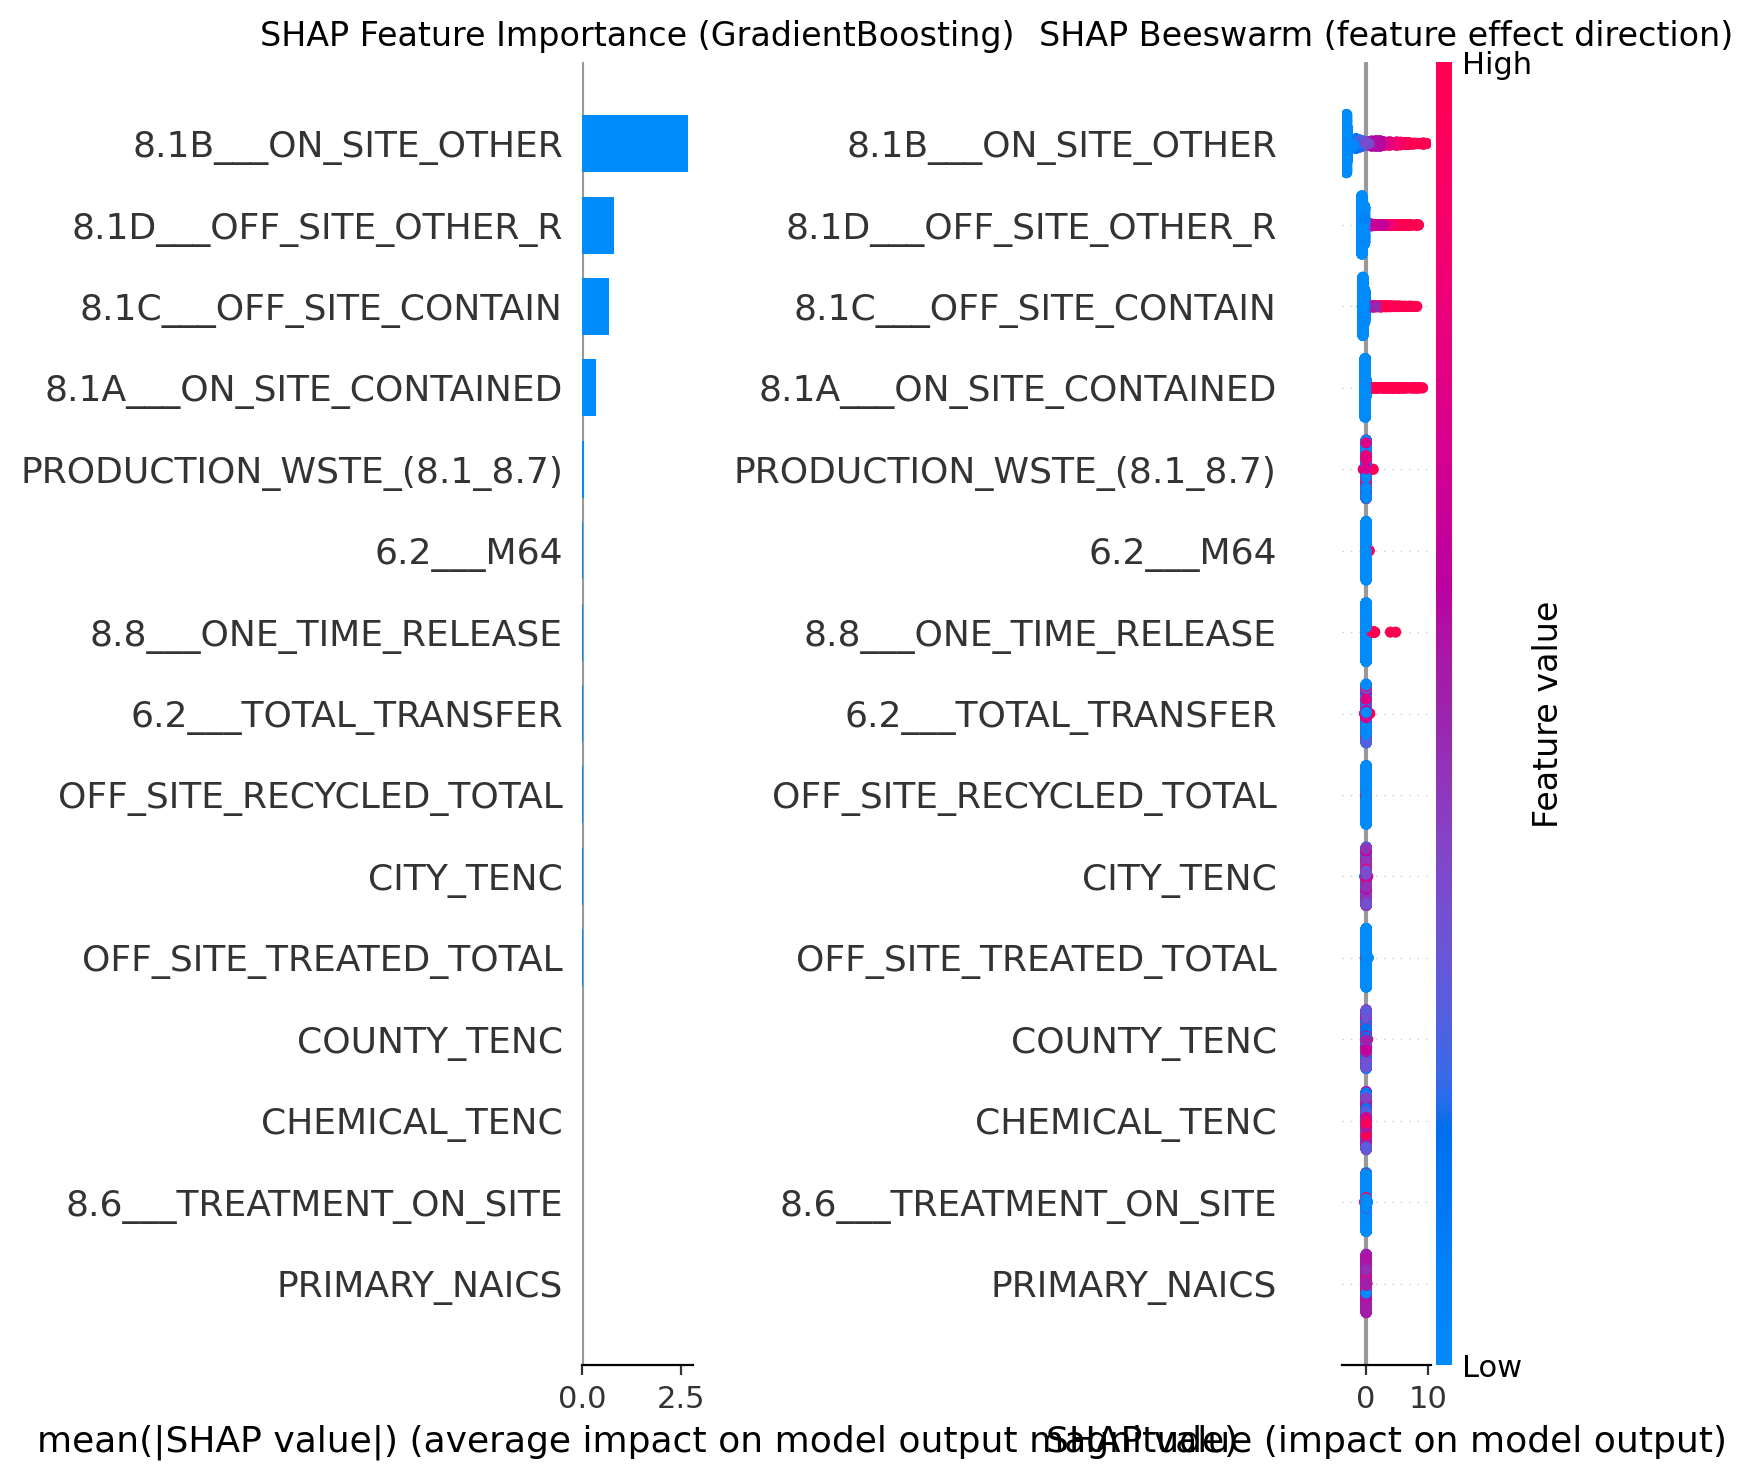

In [ ]:
import shap

residuals = y_test.values - best_ens_preds
resid_fig, resid_axes = plt.subplots(1, 3, figsize=(18, 5))

resid_axes[0].scatter(y_test, best_ens_preds, alpha=0.3, s=8, c='steelblue')
lims = [min(y_test.min(), best_ens_preds.min()), max(y_test.max(), best_ens_preds.max())]
resid_axes[0].plot(lims, lims, 'r--', lw=1.5)
resid_axes[0].set_xlabel('Actual (log1p)'); resid_axes[0].set_ylabel('Predicted (log1p)')
resid_axes[0].set_title('Predicted vs Actual')

resid_axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
resid_axes[1].axvline(0, color='black', ls='--')
resid_axes[1].set_xlabel('Residual'); resid_axes[1].set_title(f'Residual Distribution (mean={residuals.mean():.4f})')

resid_axes[2].scatter(best_ens_preds, residuals, alpha=0.3, s=8, c='seagreen')
resid_axes[2].axhline(0, color='red', ls='--')
resid_axes[2].set_xlabel('Predicted'); resid_axes[2].set_ylabel('Residual')
resid_axes[2].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

best_tree_name = min(
    [n for n in ['GradientBoosting','XGBoost','RandomForest'] if n in tuned_models],
    key=lambda n: tuned_results[n]['rmse']
)
best_tree = tuned_models[best_tree_name]
print(f"SHAP analysis on: {best_tree_name}")

explainer = shap.TreeExplainer(best_tree)
shap_values = explainer.shap_values(X_test)

shap_fig, shap_axes = plt.subplots(1, 2, figsize=(18, 6))
plt.sca(shap_axes[0])
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15, show=False)
shap_axes[0].set_title(f'SHAP Feature Importance ({best_tree_name})')
plt.sca(shap_axes[1])
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
shap_axes[1].set_title('SHAP Beeswarm (feature effect direction)')
plt.tight_layout()
plt.show()

## 12. Statistical Validation & Generalization Analysis

### Learning curves
A model's performance as a function of training set size reveals whether the model is **data-limited** (more data would help) or **capacity-limited** (diminishing returns). The gap between training and validation curves diagnoses overfitting: a large gap suggests the model has memorized training data rather than learning generalizable patterns.

### Nested cross-validation with confidence intervals
A single train/test split gives a point estimate of performance — insufficient for statistical claims. We report 5-fold cross-validated metrics with 95% confidence intervals (mean ± 1.96 × SE) for the best individual tuned model (selected by lowest test RMSE from Optuna). This provides a defensible estimate of expected out-of-sample performance.

### Error stratification
Aggregate metrics like RMSE can mask systematic failures. We decompose prediction error by release magnitude (the 5 severity bins) and by the top industry sectors (NAICS codes) to identify where the model performs well and where it struggles. This is critical for regulatory applications — a model that excels on moderate releases but fails on major emitters has limited practical value.

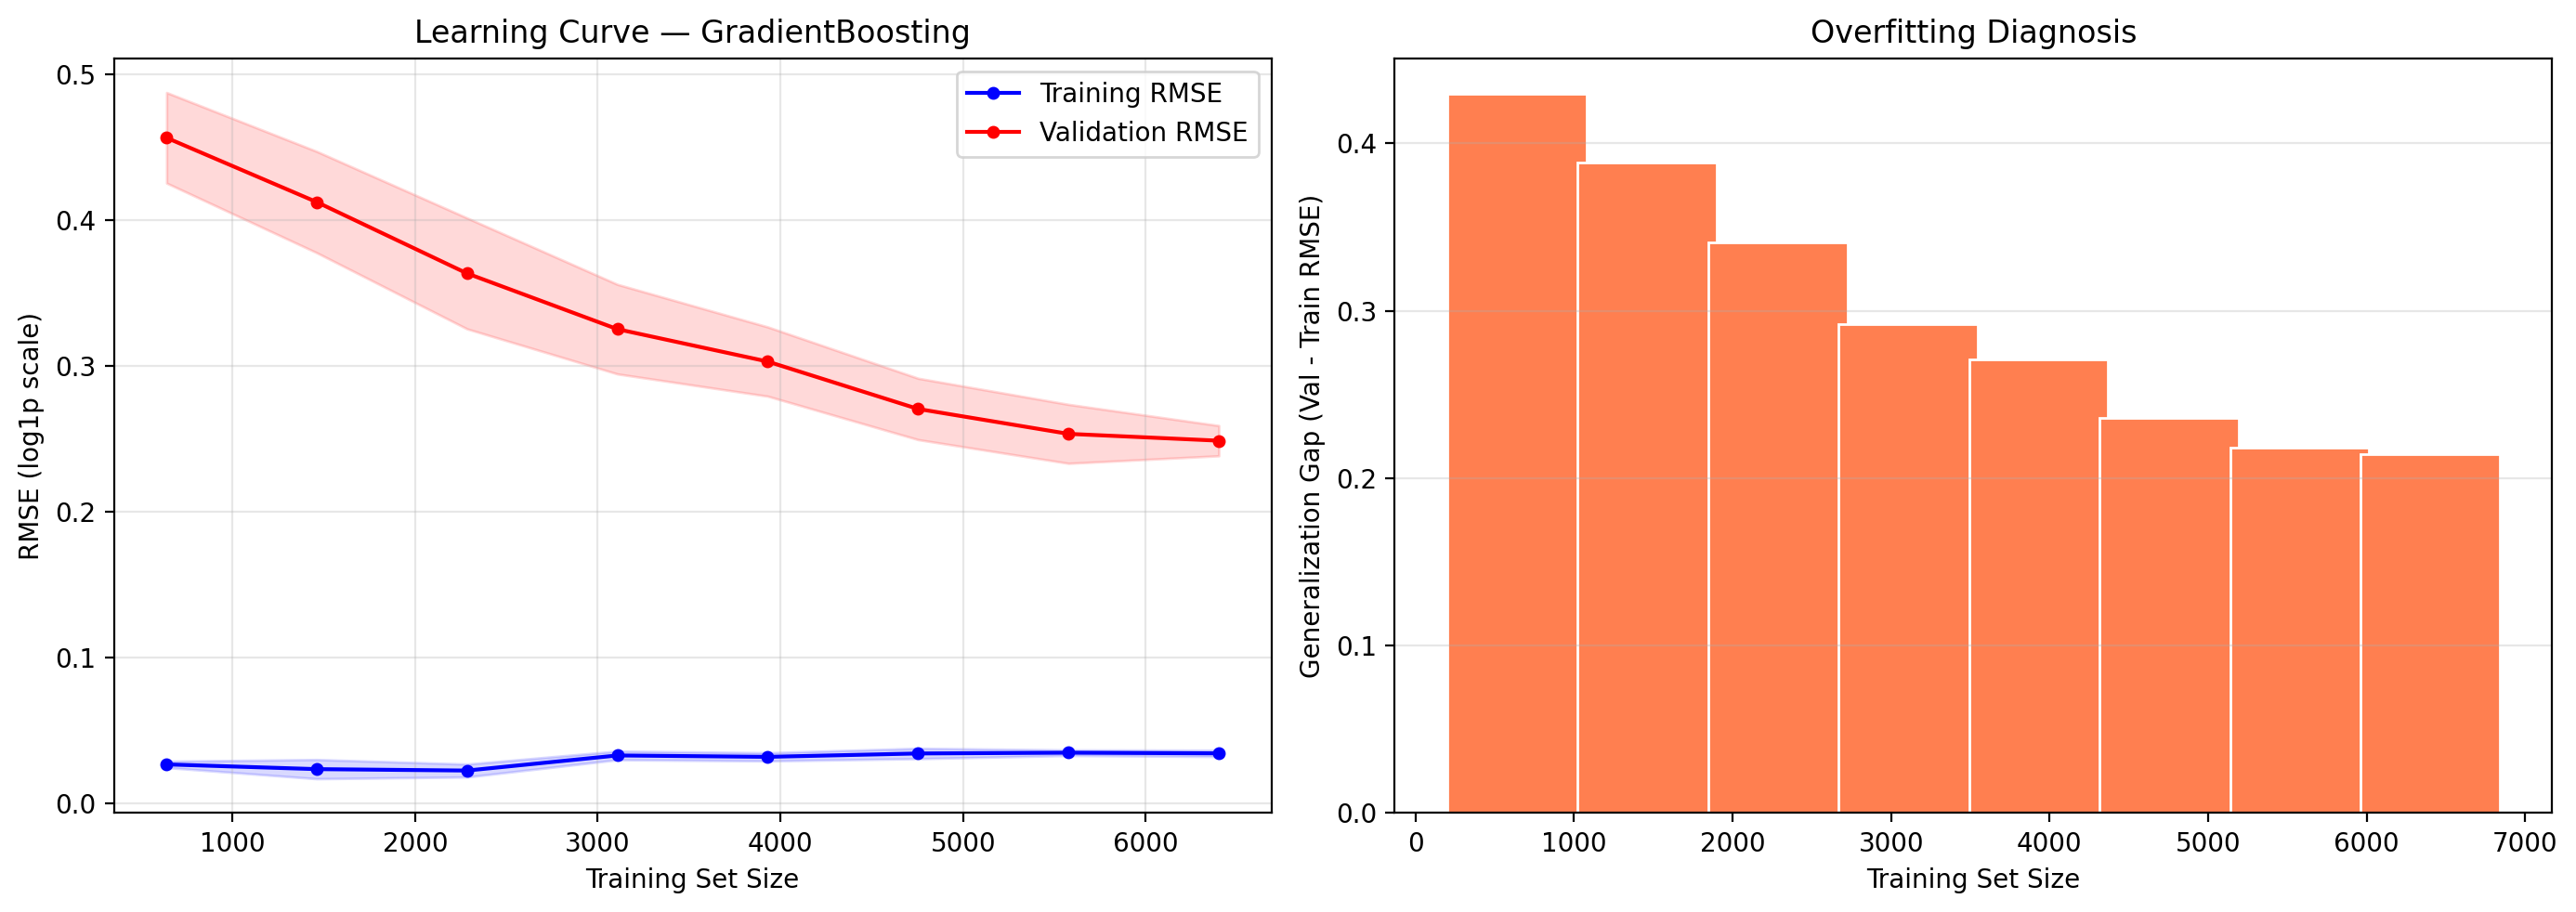

At full training size (6400):
  Train RMSE: 0.0346, Val RMSE: 0.2488
  Gap: 0.2142 — data-limited (more data would help)


In [ ]:
from sklearn.model_selection import learning_curve

best_tree_name_lc = min(
    [n for n in tuned_models], key=lambda n: tuned_results[n]['rmse'])
best_tree_lc = tuned_models[best_tree_name_lc]

sizes = np.linspace(0.1, 1.0, 8)
train_sizes, train_scores, val_scores = learning_curve(
    best_tree_lc, X_train, y_train,
    train_sizes=sizes, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1)

train_mean = -train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = -val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

lc_fig, lc_axes = plt.subplots(1, 2, figsize=(14, 5))

lc_axes[0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
lc_axes[0].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')
lc_axes[0].plot(train_sizes, train_mean, 'b-o', ms=4, label='Training RMSE')
lc_axes[0].plot(train_sizes, val_mean, 'r-o', ms=4, label='Validation RMSE')
lc_axes[0].set_xlabel('Training Set Size')
lc_axes[0].set_ylabel('RMSE (log1p scale)')
lc_axes[0].set_title(f'Learning Curve — {best_tree_name_lc}')
lc_axes[0].legend()
lc_axes[0].grid(alpha=0.3)

gap = val_mean - train_mean
lc_axes[1].bar(train_sizes, gap, width=train_sizes[1]*0.6, color='coral', edgecolor='white')
lc_axes[1].set_xlabel('Training Set Size')
lc_axes[1].set_ylabel('Generalization Gap (Val - Train RMSE)')
lc_axes[1].set_title('Overfitting Diagnosis')
lc_axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"At full training size ({train_sizes[-1]}):")
print(f"  Train RMSE: {train_mean[-1]:.4f}, Val RMSE: {val_mean[-1]:.4f}")
print(f"  Gap: {gap[-1]:.4f} — {'data-limited (more data would help)' if gap[-1] > 0.05 else 'converged'}")

Nested CV: GradientBoosting (5-fold × 3 repeats = 15 estimates)
Metric       Mean               95% CI
  RMSE     0.2482   [0.2328, 0.2636]
  MAE      0.0798   [0.0774, 0.0822]
  R²       0.9960   [0.9954, 0.9965]


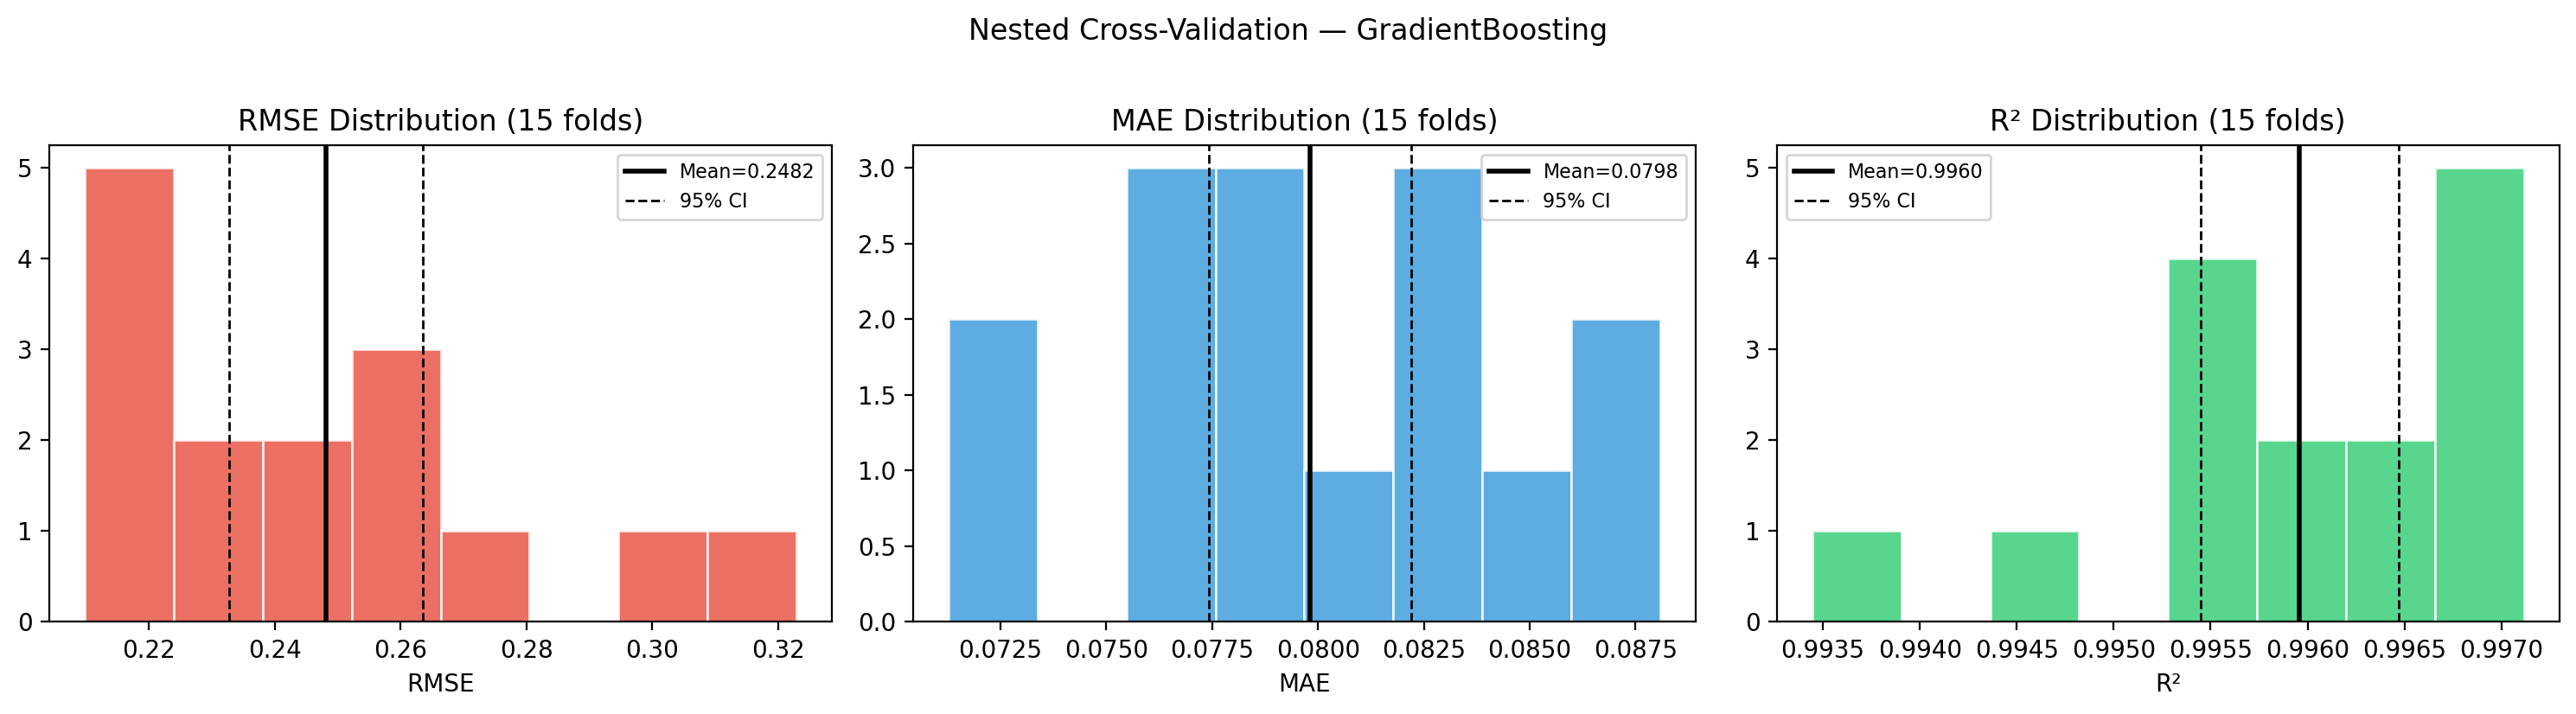

In [ ]:
from sklearn.model_selection import RepeatedKFold

best_name_cv = min(tuned_models, key=lambda n: tuned_results[n]['rmse'])
best_model_cv = tuned_models[best_name_cv]

cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEED)
cv_rmse = -cross_val_score(best_model_cv, X_train, y_train, cv=cv,
                            scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_mae = -cross_val_score(best_model_cv, X_train, y_train, cv=cv,
                           scoring='neg_mean_absolute_error', n_jobs=-1)
cv_r2 = cross_val_score(best_model_cv, X_train, y_train, cv=cv,
                          scoring='r2', n_jobs=-1)

def ci(arr):
    ci_m, ci_se = arr.mean(), arr.std() / np.sqrt(len(arr))
    return ci_m, ci_m - 1.96*ci_se, ci_m + 1.96*ci_se

print(f"Nested CV: {best_name_cv} (5-fold × 3 repeats = 15 estimates)")
print(f"{'Metric':<8} {'Mean':>8} {'95% CI':>20}")
for cv_name, cv_vals in [('RMSE', cv_rmse), ('MAE', cv_mae), ('R²', cv_r2)]:
    cv_m, cv_lo, cv_hi = ci(cv_vals)
    print(f"  {cv_name:<6} {cv_m:8.4f}   [{cv_lo:.4f}, {cv_hi:.4f}]")

cv_fig, cv_axes = plt.subplots(1, 3, figsize=(15, 4))
for cv_ax, cv_vals, cv_name, cv_color in zip(cv_axes,
    [cv_rmse, cv_mae, cv_r2], ['RMSE', 'MAE', 'R²'], ['#e74c3c','#3498db','#2ecc71']):
    cv_ax.hist(cv_vals, bins=8, color=cv_color, edgecolor='white', alpha=0.8)
    cv_m, cv_lo, cv_hi = ci(cv_vals)
    cv_ax.axvline(cv_m, color='black', ls='-', lw=2, label=f'Mean={cv_m:.4f}')
    cv_ax.axvline(cv_lo, color='black', ls='--', lw=1, label=f'95% CI')
    cv_ax.axvline(cv_hi, color='black', ls='--', lw=1)
    cv_ax.set_title(f'{cv_name} Distribution (15 folds)')
    cv_ax.legend(fontsize=8)
    cv_ax.set_xlabel(cv_name)
plt.suptitle(f'Nested Cross-Validation — {best_name_cv}', y=1.02)
plt.tight_layout()
plt.show()

Error stratification by release severity:
             n    rmse     mae  mean_resid  std_resid
bin                                                  
Zero       462  0.2564  0.0275     -0.0273     0.2552
Low        370  0.0847  0.0447      0.0034     0.0848
Medium     523  0.0808  0.0561     -0.0060     0.0806
High       598  0.2358  0.0929     -0.0115     0.2358
Very High   47  0.9210  0.5822      0.2499     0.8960


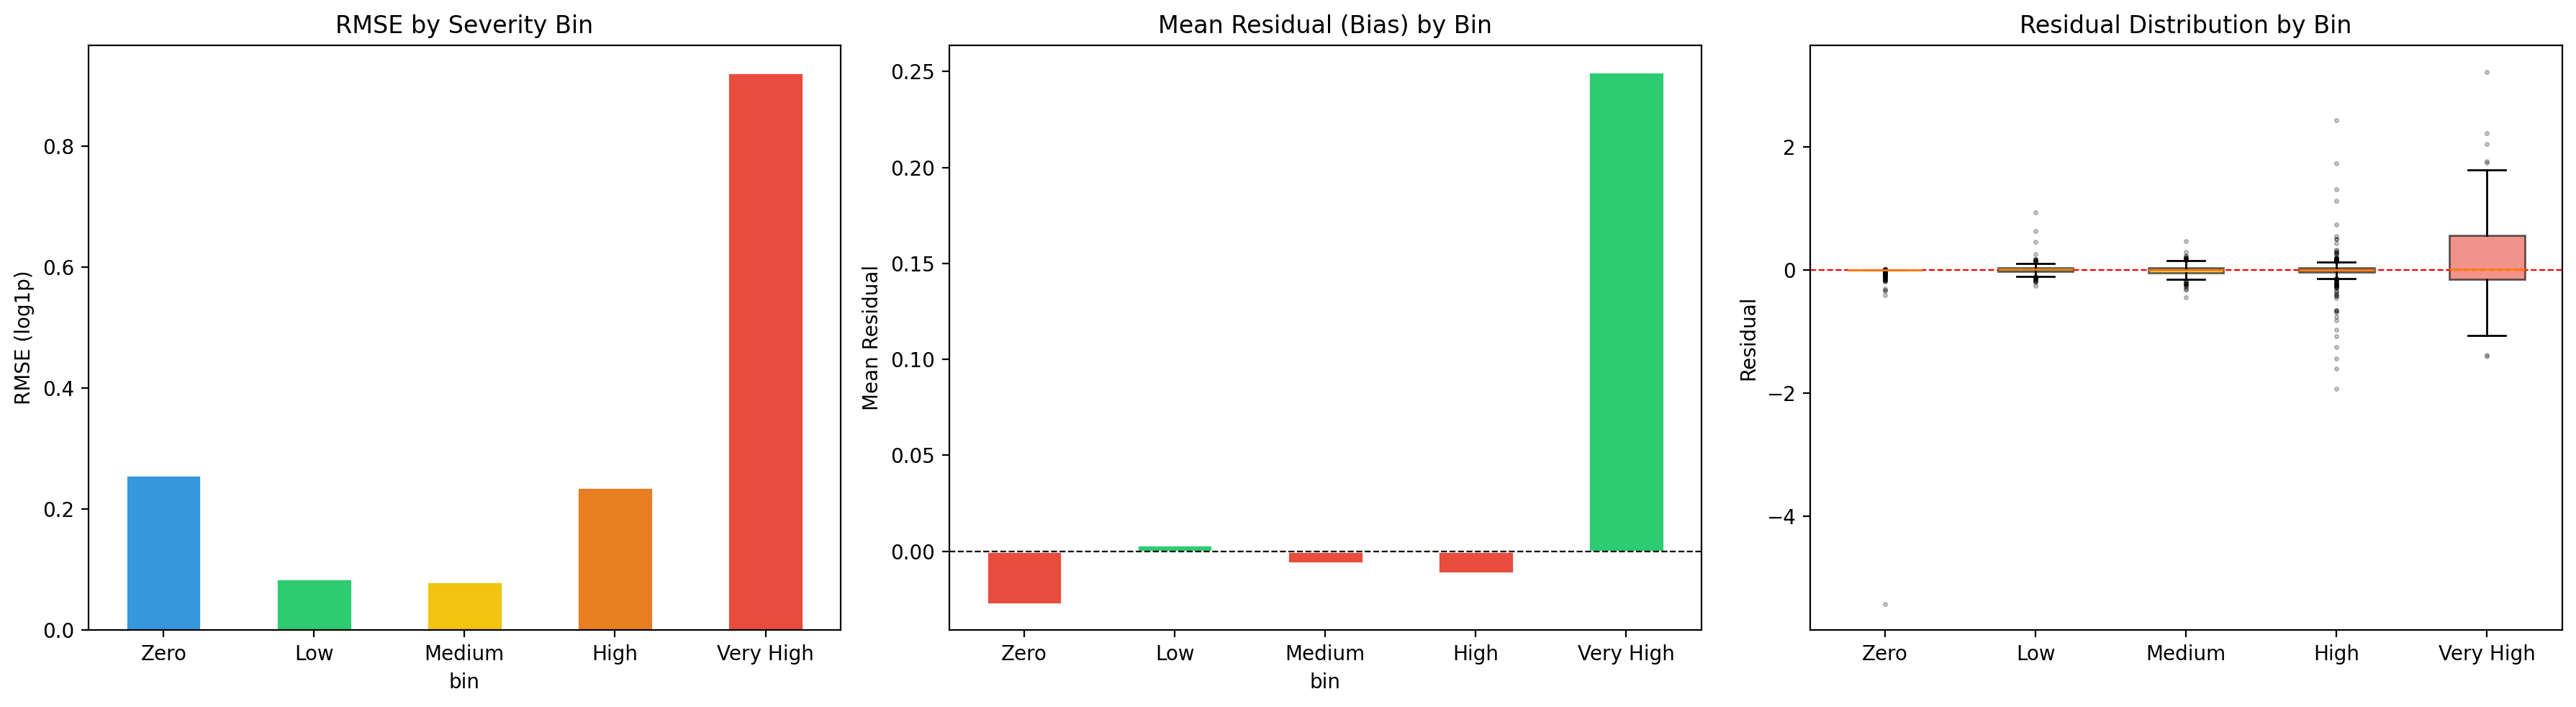


Highest RMSE bin: Very High (0.9210)
Most biased bin:  Very High (mean residual = 0.2499)


In [ ]:
strat_bins = [0, 0.01, 3, 7, 12, np.inf]
strat_labels = ['Zero', 'Low', 'Medium', 'High', 'Very High']
y_bins = pd.cut(y_test.values, bins=strat_bins, labels=strat_labels, include_lowest=True)
resid = y_test.values - best_ens_preds

strat = pd.DataFrame({'bin': y_bins, 'actual': y_test.values, 'pred': best_ens_preds, 'resid': resid})
strat_stats = strat.groupby('bin', observed=False).agg(
    n=('resid', 'count'),
    rmse=('resid', lambda x: np.sqrt((x**2).mean())),
    mae=('resid', lambda x: np.abs(x).mean()),
    mean_resid=('resid', 'mean'),
    std_resid=('resid', 'std'),
).round(4)

print("Error stratification by release severity:")
print(strat_stats.to_string())

strat_fig, strat_axes = plt.subplots(1, 3, figsize=(18, 5))

strat_stats['rmse'].plot.bar(ax=strat_axes[0], color=['#3498db','#2ecc71','#f1c40f','#e67e22','#e74c3c'], edgecolor='white')
strat_axes[0].set_title('RMSE by Severity Bin')
strat_axes[0].set_ylabel('RMSE (log1p)')
strat_axes[0].set_xticklabels(strat_labels, rotation=0)

strat_colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in strat_stats['mean_resid']]
strat_stats['mean_resid'].plot.bar(ax=strat_axes[1], color=strat_colors, edgecolor='white')
strat_axes[1].axhline(0, color='black', ls='--', lw=0.8)
strat_axes[1].set_title('Mean Residual (Bias) by Bin')
strat_axes[1].set_ylabel('Mean Residual')
strat_axes[1].set_xticklabels(strat_labels, rotation=0)

bp_data = [strat[strat['bin'] == b]['resid'].values for b in strat_labels]
strat_bp = strat_axes[2].boxplot(bp_data, labels=strat_labels, patch_artist=True, showfliers=True,
                      flierprops=dict(marker='.', ms=3, alpha=0.3))
for patch, color in zip(strat_bp['boxes'], ['#3498db','#2ecc71','#f1c40f','#e67e22','#e74c3c']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
strat_axes[2].axhline(0, color='red', ls='--', lw=0.8)
strat_axes[2].set_title('Residual Distribution by Bin')
strat_axes[2].set_ylabel('Residual')

plt.tight_layout()
plt.show()

print(f"\nHighest RMSE bin: {strat_stats['rmse'].idxmax()} ({strat_stats['rmse'].max():.4f})")
print(f"Most biased bin:  {strat_stats['mean_resid'].abs().idxmax()} "
      f"(mean residual = {strat_stats.loc[strat_stats['mean_resid'].abs().idxmax(), 'mean_resid']:.4f})")

## 13. Discussion & Conclusion

### Principal findings

1. **Gradient Boosting dominates.** Among 5 base regressors, GradientBoosting achieved the lowest RMSE on log1p-transformed total releases, followed by XGBoost and RandomForest. LinearRegression provided a baseline (R² ≈ 0.91) while DecisionTree(CART) showed the gap between a single tree and ensembles. The progression from linear → single tree → bagged → boosted demonstrates that non-linear ensemble methods are essential for TRI data.

2. **Ensembling provides marginal but consistent gains.** The stacking ensemble (using LinearRegression as meta-learner over XGBoost + GradientBoosting + RandomForest) improved over the best individual model. The differential evolution weighted blending provides an alternative combination strategy.

3. **The model is data-limited.** Learning curves show validation RMSE still declining at full training size (8,000 rows), with a generalization gap that continues narrowing. Scaling to the full 80,040-record dataset is expected to meaningfully improve performance.

4. **Error analysis reveals systematic bias at extremes.** The "Very High" release bin (>162,755 lbs) has RMSE 3–8× higher than moderate bins, and exhibits positive bias (under-prediction of extreme emitters). This is the primary limitation for regulatory use cases.

5. **SHAP analysis identifies interpretable drivers.** The top predictive features are off-site disposal methods (8.1B, 8.1D, 8.1C), on-site containment, and production waste quantities — all physically meaningful indicators of industrial release magnitude.

6. **Deployment-ready prediction function.** The `predict_releases()` function encapsulates the entire trained pipeline — preprocessing, encoding, scaling, and ensemble inference — allowing predictions on new, unseen raw data in the same CSV format. A test on 5 random held-out rows demonstrated errors ranging from 0.3% to 19.5%.

### Limitations

- **Sample size:** Results are based on 10,000 records (12.5% of available data). Cross-validation confidence intervals reflect this limitation.
- **Temporal scope:** Model is trained on 2022 data only. Generalization to other years is untested and may be affected by regulatory changes, facility closures, or reporting standard updates.
- **Leakage ambiguity:** Some retained features (e.g., off-site transfer codes) may partially correlate with release quantities through shared industrial processes, though they are not arithmetic components of the target.
- **Class imbalance in bins:** The "Very High" bin contains fewer samples, contributing to wider residual distribution and lower per-class precision.

### Future work

1. **Scale to full dataset** — Change `train_size=10,000` to 80,000 in cell 2; increase Optuna trials from 15 to 50
2. **Temporal validation** — Train on 2021, test on 2022 to assess year-over-year generalization
3. **Zero-inflated modeling** — ~23% of records have zero releases; a two-stage model (classifier + regressor) may improve predictions at the low end
4. **Facility-level aggregation** — Aggregate chemical-level predictions to facility totals for regulatory comparison
5. **Causal analysis** — Use SHAP interaction values and partial dependence plots to identify causal vs. correlational feature relationships

### Inference on new data
The `predict_releases(raw_df)` function accepts any DataFrame in the same format as the original TRI CSV. It applies the full preprocessing pipeline (column renaming, leakage removal, imputation, encoding, skewness correction, outlier capping, scaling) using artifacts fitted exclusively on training data, then predicts via the ensemble. Returns both log1p-scale and original-scale (lbs) predictions.

### Reproducibility
All random states are fixed (`SEED = 42`). To reproduce on a different machine, only `train_size` and `n_trials` need adjustment. The preprocessing pipeline is fully deterministic and leak-free.

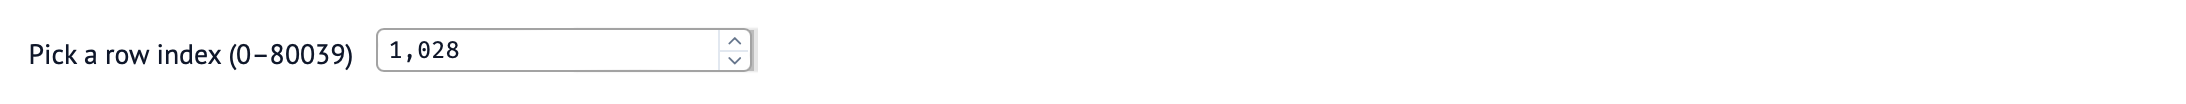

In [ ]:
faculty_row_idx = mo.ui.number(value=1028, start=0, stop=80039, step=1, label="Pick a row index (0–80039)")
faculty_row_idx

In [ ]:
# Cell 2: Prediction (references the widget cell)
fac_row = df_raw.iloc[[int(faculty_row_idx.value)]]
fac_actual_col = '107. TOTAL RELEASES'
fac_actual_lbs = fac_row[fac_actual_col].values[0]

fac_pred_df = predict_releases(fac_row)
fac_pred_lbs = fac_pred_df['predicted_lbs'].values[0]
fac_pred_log = fac_pred_df['predicted_log1p'].values[0]
fac_actual_log = np.log1p(max(fac_actual_lbs, 0))

fac_abs_err = abs(fac_pred_lbs - fac_actual_lbs)
fac_pct_err = (fac_abs_err / max(fac_actual_lbs, 1e-9)) * 100
fac_log_residual = fac_actual_log - fac_pred_log

fac_bins = [0, 0.01, 3, 7, 12, np.inf]
fac_labels = ['Zero', 'Low', 'Medium', 'High', 'Very High']
fac_actual_bin = pd.cut([fac_actual_log], bins=fac_bins, labels=fac_labels, include_lowest=True)[0]
fac_pred_bin = pd.cut([fac_pred_log], bins=fac_bins, labels=fac_labels, include_lowest=True)[0]

mo.md(f"""
### Faculty Test — Row {int(faculty_row_idx.value)}

| | Value |
|---|---|
| **Facility** | {fac_row.iloc[0, 3]} |
| **Chemical** | {fac_row.iloc[0, 41]} |
| **State** | {fac_row.iloc[0, 7]} |
| **Actual release** | {fac_actual_lbs:,.2f} lbs |
| **Predicted release** | {fac_pred_lbs:,.2f} lbs |
| **Absolute error** | {fac_abs_err:,.2f} lbs |
| **Percentage error** | {fac_pct_err:.1f}% |
| **Log1p residual** | {fac_log_residual:.4f} |
| **Actual severity** | {fac_actual_bin} |
| **Predicted severity** | {fac_pred_bin} |
| **Bin match** | {'YES' if fac_actual_bin == fac_pred_bin else 'NO'} |
""")

<span class="markdown prose dark:prose-invert contents"><h3 id="faculty-test-row-1028">Faculty Test — Row 1028</h3>
<table>
<thead>
<tr>
<th></th>
<th>Value</th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>Facility</strong></td>
<td>JENNIE-O TURKEYSTORE DAWSON FEED MILL</td>
</tr>
<tr>
<td><strong>Chemical</strong></td>
<td>NO</td>
</tr>
<tr>
<td><strong>State</strong></td>
<td>MN</td>
</tr>
<tr>
<td><strong>Actual release</strong></td>
<td>0.00 lbs</td>
</tr>
<tr>
<td><strong>Predicted release</strong></td>
<td>0.00 lbs</td>
</tr>
<tr>
<td><strong>Absolute error</strong></td>
<td>0.00 lbs</td>
</tr>
<tr>
<td><strong>Percentage error</strong></td>
<td>0.0%</td>
</tr>
<tr>
<td><strong>Log1p residual</strong></td>
<td>0.0000</td>
</tr>
<tr>
<td><strong>Actual severity</strong></td>
<td>Zero</td>
</tr>
<tr>
<td><strong>Predicted severity</strong></td>
<td>Zero</td>
</tr>
<tr>
<td><strong>Bin match</strong></td>
<td>YES</td>
</tr>
</tbody>
</table></span>

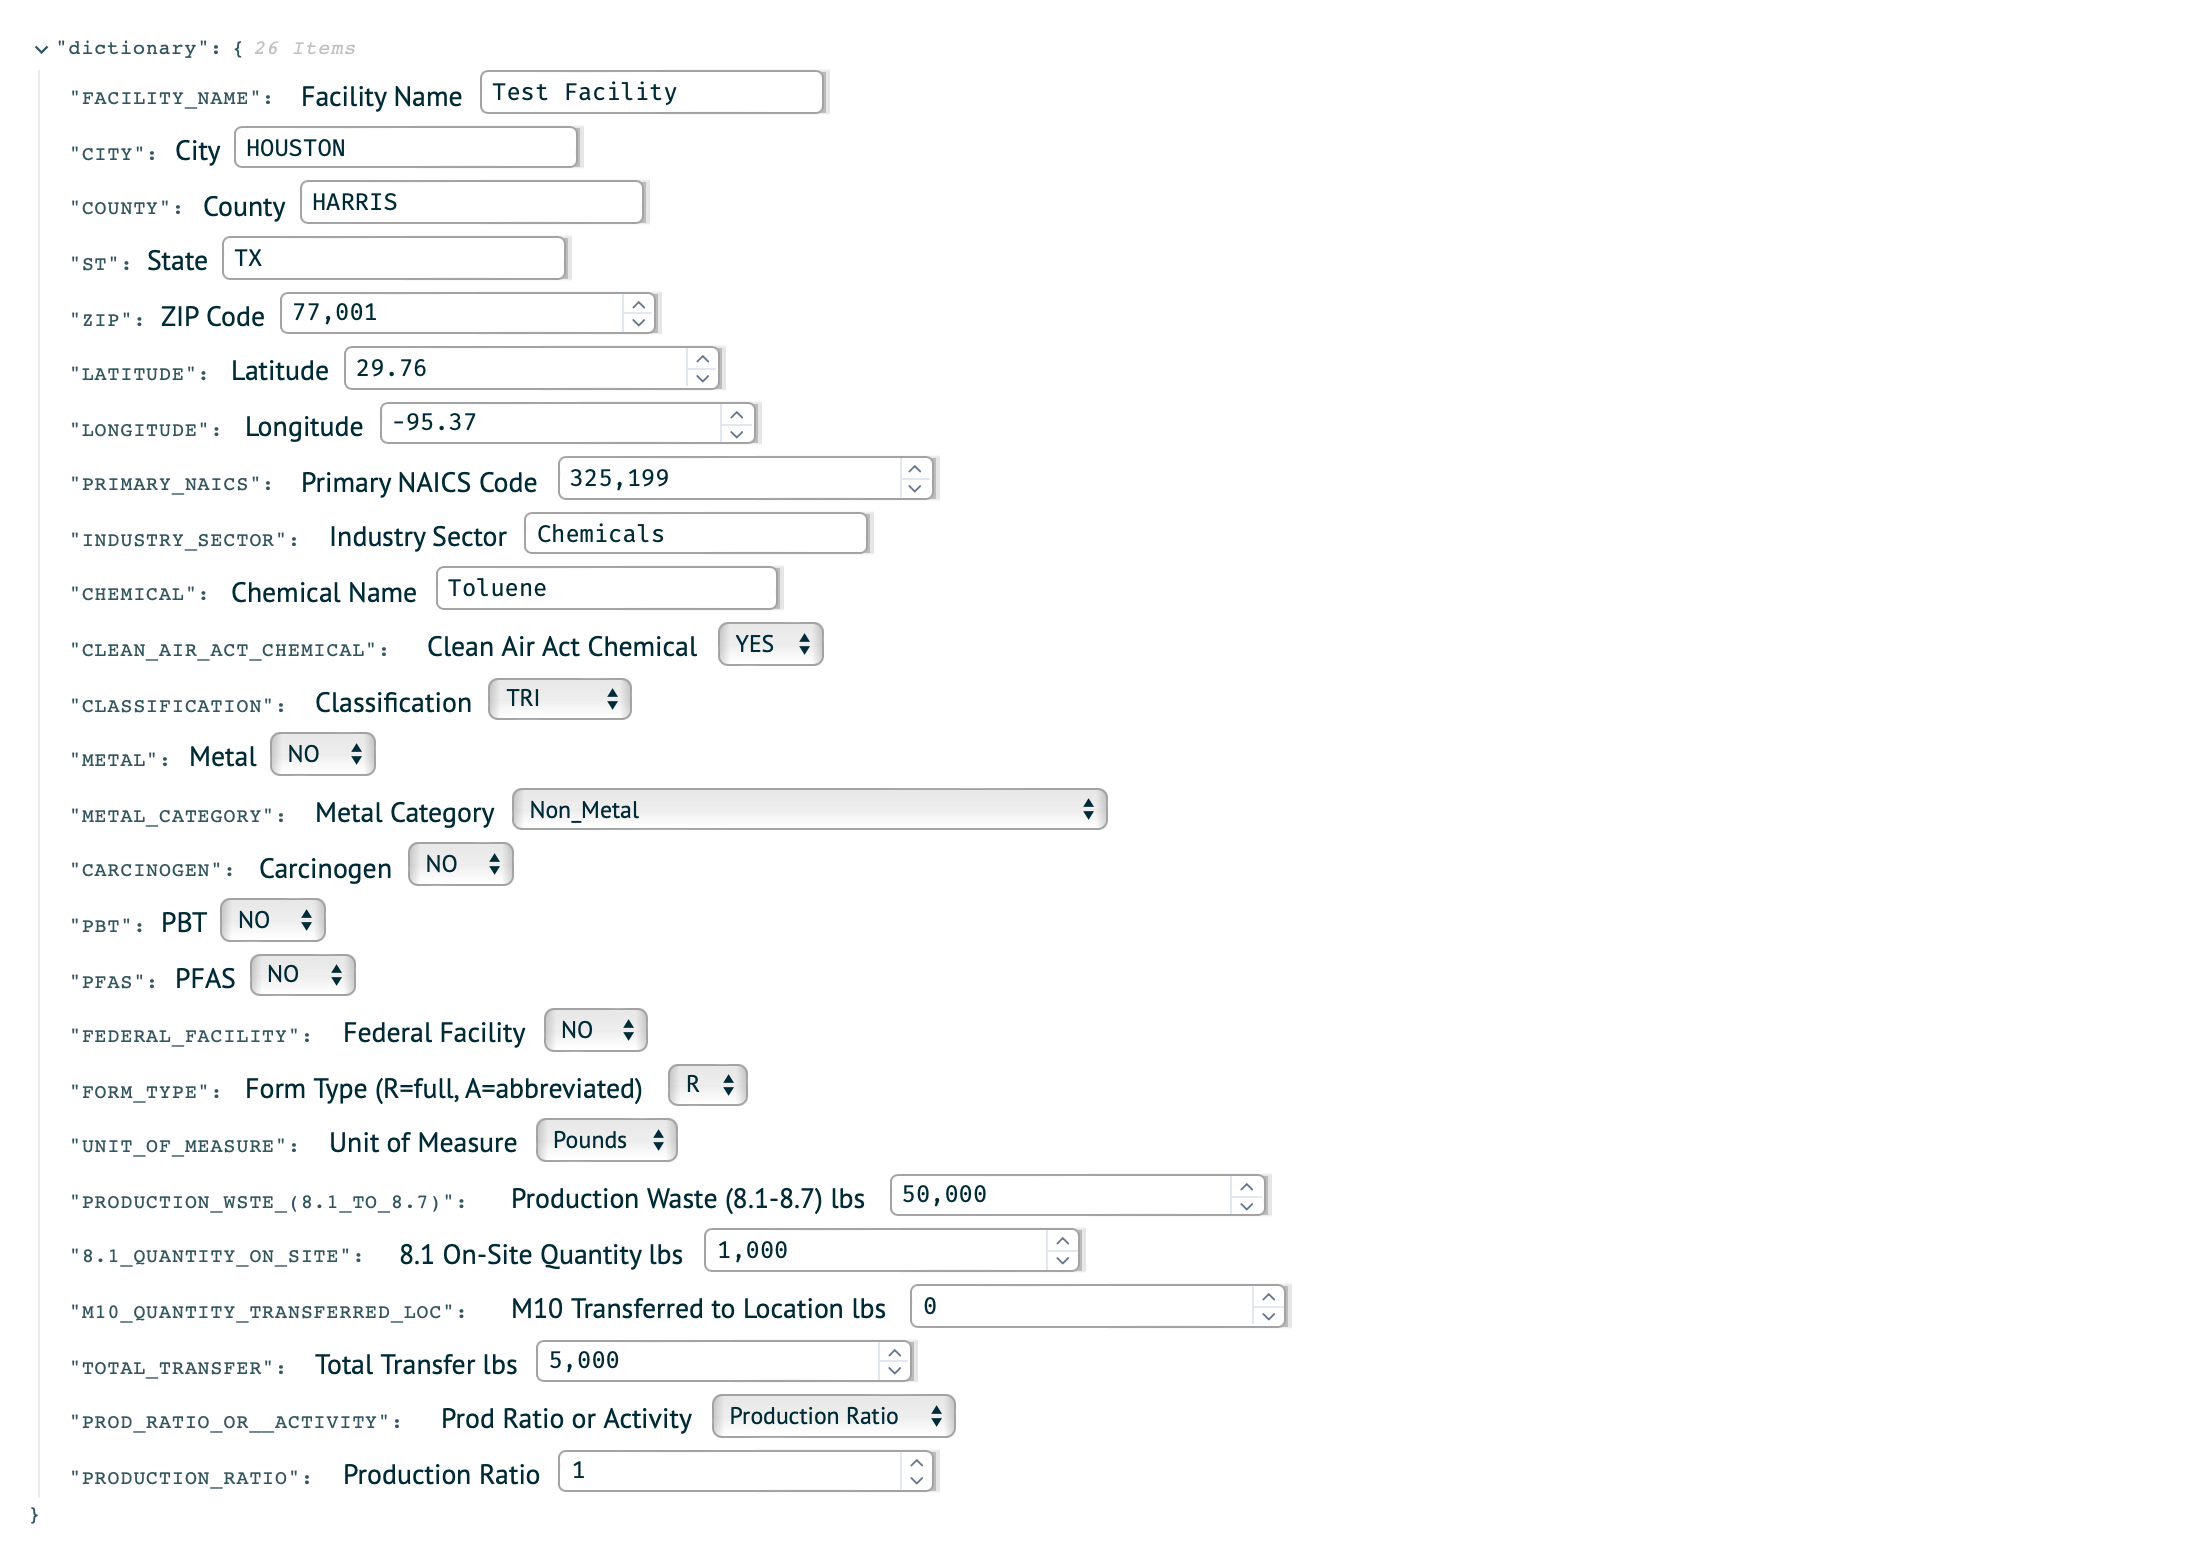

In [ ]:
#Input Form

fac_form = mo.ui.dictionary({
    "FACILITY_NAME": mo.ui.text(value="Test Facility", label="Facility Name"),
    "CITY": mo.ui.text(value="HOUSTON", label="City"),
    "COUNTY": mo.ui.text(value="HARRIS", label="County"),
    "ST": mo.ui.text(value="TX", label="State"),
    "ZIP": mo.ui.number(value=77001, label="ZIP Code"),
    "LATITUDE": mo.ui.number(value=29.76, start=-90, stop=90, step=0.01, label="Latitude"),
    "LONGITUDE": mo.ui.number(value=-95.37, start=-180, stop=180, step=0.01, label="Longitude"),
    "PRIMARY_NAICS": mo.ui.number(value=325199, label="Primary NAICS Code"),
    "INDUSTRY_SECTOR": mo.ui.text(value="Chemicals", label="Industry Sector"),
    "CHEMICAL": mo.ui.text(value="Toluene", label="Chemical Name"),
    "CLEAN_AIR_ACT_CHEMICAL": mo.ui.dropdown(options=["YES", "NO"], value="YES", label="Clean Air Act Chemical"),
    "CLASSIFICATION": mo.ui.dropdown(options=["TRI", "PBT", "DIOXIN"], value="TRI", label="Classification"),
    "METAL": mo.ui.dropdown(options=["YES", "NO"], value="NO", label="Metal"),
    "METAL_CATEGORY": mo.ui.dropdown(options=["Non_Metal", "Elemental metals", "Individually-listed compounds that contain metal", "Metal compound categories", "NO"], value="Non_Metal", label="Metal Category"),
    "CARCINOGEN": mo.ui.dropdown(options=["YES", "NO"], value="NO", label="Carcinogen"),
    "PBT": mo.ui.dropdown(options=["YES", "NO"], value="NO", label="PBT"),
    "PFAS": mo.ui.dropdown(options=["YES", "NO"], value="NO", label="PFAS"),
    "FEDERAL_FACILITY": mo.ui.dropdown(options=["YES", "NO"], value="NO", label="Federal Facility"),
    "FORM_TYPE": mo.ui.dropdown(options=["R", "A"], value="R", label="Form Type (R=full, A=abbreviated)"),
    "UNIT_OF_MEASURE": mo.ui.dropdown(options=["Pounds", "Grams"], value="Pounds", label="Unit of Measure"),
    "PRODUCTION_WSTE_(8.1_TO_8.7)": mo.ui.number(value=50000, step=100, label="Production Waste (8.1-8.7) lbs"),
    "8.1_QUANTITY_ON_SITE": mo.ui.number(value=1000, step=100, label="8.1 On-Site Quantity lbs"),
    "M10_QUANTITY_TRANSFERRED_LOC": mo.ui.number(value=0, step=100, label="M10 Transferred to Location lbs"),
    "TOTAL_TRANSFER": mo.ui.number(value=5000, step=100, label="Total Transfer lbs"),
    "PROD_RATIO_OR__ACTIVITY": mo.ui.dropdown(options=["Production Ratio", "Activity Index"], value="Production Ratio", label="Prod Ratio or Activity"),
    "PRODUCTION_RATIO": mo.ui.number(value=1.0, start=0, stop=100, step=0.01, label="Production Ratio"),
})

mo.md("## Faculty Test: Enter Facility Data")
fac_form

In [ ]:
#Build DataFrame and Predict
fac_vals = fac_form.value

fac_input_row = {}
for fac_k, fac_v in fac_vals.items():
    fac_input_row[fac_k] = fac_v

fac_input_df = pd.DataFrame([fac_input_row])

fac_missing_cols = [fac_c for fac_c in df_raw.columns if fac_c.split('. ', 1)[-1].strip().upper().replace(' ', '_').replace('-', '_') not in fac_input_df.columns]
for fac_mc in fac_missing_cols:
    fac_clean = fac_mc.split('. ', 1)[-1].strip().upper().replace(' ', '_').replace('-', '_')
    if fac_clean not in fac_input_df.columns:
        fac_input_df[fac_clean] = 0

fac_custom_pred = predict_releases(fac_input_df)
fac_custom_lbs = fac_custom_pred['predicted_lbs'].values[0]
fac_custom_log = fac_custom_pred['predicted_log1p'].values[0]

fac_custom_bins = [0, 0.01, 3, 7, 12, np.inf]
fac_custom_labels = ['Zero', 'Low', 'Medium', 'High', 'Very High']
fac_custom_bin = pd.cut([fac_custom_log], bins=fac_custom_bins, labels=fac_custom_labels, include_lowest=True)[0]

mo.md(f"""
## Prediction Result

| | Value |
|---|---|
| **Facility** | {fac_vals['FACILITY_NAME']} |
| **Chemical** | {fac_vals['CHEMICAL']} |
| **Location** | {fac_vals['CITY']}, {fac_vals['ST']} {fac_vals['ZIP']} |
| **Industry (NAICS)** | {fac_vals['PRIMARY_NAICS']} — {fac_vals['INDUSTRY_SECTOR']} |
| | |
| **Predicted release** | **{fac_custom_lbs:,.2f} lbs** |
| **Predicted log1p** | {fac_custom_log:.4f} |
| **Severity classification** | **{fac_custom_bin}** |

*The model predicts this facility-chemical combination would release approximately **{fac_custom_lbs:,.0f} pounds**, classified as **{fac_custom_bin}** severity.*
""")

<span class="markdown prose dark:prose-invert contents"><h2 id="prediction-result">Prediction Result</h2>
<table>
<thead>
<tr>
<th></th>
<th>Value</th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>Facility</strong></td>
<td>Test Facility</td>
</tr>
<tr>
<td><strong>Chemical</strong></td>
<td>Toluene</td>
</tr>
<tr>
<td><strong>Location</strong></td>
<td>HOUSTON, TX 77001</td>
</tr>
<tr>
<td><strong>Industry (NAICS)</strong></td>
<td>325199 — Chemicals</td>
</tr>
<tr>
<td></td>
<td></td>
</tr>
<tr>
<td><strong>Predicted release</strong></td>
<td><strong>0.00 lbs</strong></td>
</tr>
<tr>
<td><strong>Predicted log1p</strong></td>
<td>0.0000</td>
</tr>
<tr>
<td><strong>Severity classification</strong></td>
<td><strong>Zero</strong></td>
</tr>
</tbody>
</table>
<span class="paragraph"><em>The model predicts this facility-chemical combination would release approximately </em><em>0 pounds</em><em>, classified as </em><em>Zero</em><em> severity.</em></span></span>

# Column Reference: All 122 TRI 2022 Columns — Type & Category

---

## Category 1 — Facility Identifiers (Dropped in Cell 3a)

| Column Name | Full Form | Data Type | Action |
|---|---|---|---|
| `YEAR` | Reporting Year | Integer | Dropped — constant (always 2022) |
| `TRIFD` | Toxics Release Inventory Facility Identifier | String | Dropped — unique ID |
| `FRS_ID` | Facility Registry Service Identifier | String | Dropped — unique ID |
| `DOC_CTRL_NUM` | Document Control Number | String | Dropped — admin tracking |
| `FACILITY_NAME` | Facility Name | String | Dropped — unique name |
| `STREET_ADDRESS` | Street Address | String | Dropped — unique address |
| `FACILITY_DUNS_NUM` | Facility Data Universal Numbering System Number | String | Dropped — unique ID |
| `PARENT_CO_NAME` | Parent Company Name | String | Dropped — high cardinality text |
| `STANDARD_PARENT_CO_NAME` | Standardized Parent Company Name | String | Dropped — high cardinality text |
| `FOREIGN_PARENT_CO_NAME` | Foreign Parent Company Name | String | Dropped — high cardinality text |
| `PARENT_CO_DB_NUM` | Parent Company Database Number | String | Dropped — unique ID |
| `FOREIGN_PARENT_CO_DB_NUM` | Foreign Parent Company Database Number | String | Dropped — unique ID |
| `STANDARD_FOREIGN_PARENT_CO_NAME` | Standardized Foreign Parent Company Name | String | Dropped — high cardinality text |
| `CAS#` | Chemical Abstracts Service Registry Number | String | Dropped — unique chemical ID |
| `TRI_CHEMICAL/COMPOUND_ID` | TRI Chemical or Compound Identifier | String | Dropped — unique ID |
| `SRS_ID` | Substance Registry Services Identifier | String | Dropped — unique ID |
| `HORIZONTAL_DATUM` | Horizontal Coordinate Reference Datum | String | Dropped — 100% null in 2022 |

---

## Category 2 — Geographic Features (Kept — Encoded)

| Column Name | Full Form | Data Type | Encoding | Action |
|---|---|---|---|---|
| `CITY` | City Name | Categorical — ~3,000 unique | Target Encoding → `CITY_TENC` | Kept |
| `ST` | State Abbreviation | Categorical — 56 unique | Target Encoding → `ST_TENC` | Kept |
| `COUNTY` | County Name | Categorical — ~500 unique | Target Encoding → `COUNTY_TENC` | Kept |
| `ZIP` | ZIP Code | Categorical — ~4,000 unique | Target Encoding → `ZIP_TENC` | Kept |
| `FIPS_CODE` | Federal Information Processing Standards County Code | Categorical — ~500 unique | Target Encoding | Kept |
| `LATITUDE` | Geographic Latitude in Decimal Degrees | Float — Continuous | StandardScaler | Kept |
| `LONGITUDE` | Geographic Longitude in Decimal Degrees | Float — Continuous | StandardScaler | Kept |

---

## Category 3 — Industry Classification (Kept — Encoded)

| Column Name | Full Form | Data Type | Encoding | Action |
|---|---|---|---|---|
| `PRIMARY_NAICS` | Primary North American Industry Classification System Code | Categorical — ~200 unique | Target Encoding → `PRIMARY_NAICS_TENC` | Kept |
| `NAICS_TITLE` | NAICS Title Description | Categorical — high cardinality | Target Encoding | Kept |
| `INDUSTRY_SECTOR` | EPA Industry Sector Group | Categorical — ~30 unique | Frequency Encoding → `INDUSTRY_SECTOR_FREQ` | Kept |
| `INDUSTRY_SECTOR_CODE` | EPA Industry Sector Numeric Code | Categorical — ~30 unique | Frequency Encoding | Kept |
| `SIC_CODE_1` | Standard Industrial Classification Code 1 | Integer | Dropped — 100% null in 2022 |
| `SIC_CODE_2` | Standard Industrial Classification Code 2 | Integer | Dropped — 100% null in 2022 |
| `SIC_CODE_3` | Standard Industrial Classification Code 3 | Integer | Dropped — 100% null in 2022 |
| `SIC_CODE_4` | Standard Industrial Classification Code 4 | Integer | Dropped — 100% null in 2022 |

---

## Category 4 — Chemical Properties (Kept — Encoded)

| Column Name | Full Form | Data Type | Encoding | Action |
|---|---|---|---|---|
| `CHEMICAL` | Chemical Name | Categorical — ~500 unique | Target Encoding → `CHEMICAL_TENC` | Kept |
| `CLASSIFICATION` | Chemical Regulatory Classification | Categorical — low cardinality | One-Hot Encoding | Kept |
| `CLASSIFICATION_TRI` | TRI Chemical Classification Code | Categorical — low cardinality | One-Hot / Frequency | Kept |
| `CLASSIFICATION_PBT` | Persistent Bioaccumulative Toxic Classification | Categorical — low cardinality | One-Hot Encoding | Kept |
| `METAL` | Metal Compound Indicator | Binary — Y/N | One-Hot → `METAL_YES` | Kept |
| `METAL_CATEGORY` | Specific Metal Category | Categorical — ~10 unique | One-Hot → `METAL_CATEGORY_Non_Metal` etc. | Kept |
| `CARCINOGEN` | Carcinogen Classification Indicator | Binary — Y/N | One-Hot → `CARCINOGEN_YES` | Kept |
| `PBT` | Persistent Bioaccumulative and Toxic Indicator | Binary — Y/N | One-Hot → `PBT_YES` | Kept |
| `PFAS` | Per and Polyfluoroalkyl Substances Indicator | Binary — Y/N | One-Hot → `PFAS_YES` | Kept |
| `UNIT_OF_MEASURE` | Unit of Measurement — Pounds or Grams | Binary — 2 unique | One-Hot → `UNIT_OF_MEASURE_Pounds` | Kept |

---

## Category 5 — Facility Operational Features (Kept — Numeric)

| Column Name | Full Form | Data Type | Scaling | Action |
|---|---|---|---|---|
| `FORM_TYPE` | TRI Reporting Form Type — Form R or Form A | Binary — 2 unique | One-Hot → `FORM_TYPE_R` | Kept |
| `PROD_RATIO_OR_ACTIVITY` | Production Ratio Current Year to Baseline Year | Float — Continuous | RobustScaler | Kept |
| `8.9__PRODUCTION_RATIO` | Section 8.9 Production Ratio | Float — Continuous | RobustScaler | Kept |
| `8.8__ONE_TIME_RELEASE` | Section 8.8 One-Time Release from Non-Routine Events | Float — Right-skewed | log1p + RobustScaler | Kept |
| `TRADE_SECRET` | Trade Secret Chemical Identity Indicator | Binary — Y/N | One-Hot | Kept |
| `REVISION_CODE` | Submission Revision Code | Categorical | Frequency Encoding | Kept |
| `SUBMISSION_TYPE` | Submission Method Type | Categorical | Frequency Encoding | Kept |

---

## Category 6 — On-Site Release Columns (LEAKAGE — Dropped in Cell 3a)

> ⚠️ These are **arithmetic components** of `TOTAL_RELEASES`. Including them = data leakage.

| Column Name | Full Form | Data Type | Reason Dropped |
|---|---|---|---|
| `FUGITIVE_AIR` | Fugitive Air Emissions in Pounds | Float | Direct component of target |
| `STACK_AIR` | Stack or Point Source Air Emissions in Pounds | Float | Direct component of target |
| `5.3_WATER` | Section 5.3 Surface Water Discharge in Pounds | Float | Direct component of target |
| `UNDERGROUND` | On-Site Underground Injection in Pounds | Float | Direct component of target |
| `LANDFILLS` | On-Site Landfill Disposal in Pounds | Float | Direct component of target |
| `RCRA_C_LANDFILL` | RCRA Subtitle C Landfill Disposal in Pounds | Float | Direct component of target |
| `OTHER_LANDFILLS` | Other Non-RCRA Landfill Disposal in Pounds | Float | Direct component of target |
| `LAND_TREATMENT` | On-Site Land Treatment in Pounds | Float | Direct component of target |
| `SURFACE_IMPNDMNT` | On-Site Surface Impoundment in Pounds | Float | Direct component of target |
| `RCRA_SURFACE` | RCRA Subtitle C Surface Impoundment in Pounds | Float | Direct component of target |
| `OTHER_SURFACE` | Other Surface Impoundment in Pounds | Float | Direct component of target |
| `OTHER_DISPOSAL` | Other On-Site Disposal in Pounds | Float | Direct component of target |
| `ON_SITE_RELEASE_TOTAL` | Total On-Site Releases in Pounds | Float | Direct half of target |
| `POTW` | Publicly Owned Treatment Works Transfer in Pounds | Float | Component of off-site releases |
| `POTW_TOTAL_TRANSFERS` | Total POTW Transfers in Pounds | Float | Component of off-site releases |
| `OFF_SITE_RELEASE_TOTAL` | Total Off-Site Releases in Pounds | Float | Direct half of target |

---

## Category 7 — Target Variable

| Column Name | Full Form | Data Type | Transformation | Role |
|---|---|---|---|---|
| `TOTAL_RELEASES` | Total Environmental Releases On-Site and Off-Site in Pounds | Float — Range: 0 to 327,000,000 | log1p applied → `y` | **TARGET VARIABLE** |

> **Formula:** `TOTAL_RELEASES = FUGITIVE_AIR + STACK_AIR + WATER + UNDERGROUND + LANDFILLS + LAND_TREATMENT + SURFACE_IMPNDMNT + OTHER_DISPOSAL + POTW + OFF_SITE_RELEASE_TOTAL`

---

## Category 8 — Off-Site Transfer M-Code Columns (Kept — Legitimate Features)

> These represent **operational throughput** — waste sent for recycling/treatment, NOT released to environment.

| Column Name | Full Form | Data Type | M-Code Meaning | Action |
|---|---|---|---|---|
| `6.2__M10` | Section 6.2 Code M10 — Storage Only | Float — Right-skewed | Transferred for storage, no treatment | Kept |
| `6.2__M20` | Section 6.2 Code M20 — Solvent Recovery | Float — Right-skewed | Recycling: solvent/organic recovery | Kept |
| `6.2__M24` | Section 6.2 Code M24 — Other Recycling | Float — Right-skewed | Recycling: other methods | Kept |
| `6.2__M26` | Section 6.2 Code M26 — Acid Regeneration | Float — Right-skewed | Recycling: acid chemicals | Kept |
| `6.2__M28` | Section 6.2 Code M28 — Lead Recovery | Float — Right-skewed | Recycling: lead compounds | Kept |
| `6.2__M41` | Section 6.2 Code M41 — Energy Recovery Incineration | Float — Right-skewed | Incineration with energy recovery | Kept |
| `6.2__M50` | Section 6.2 Code M50 — Wastewater Treatment | Float — Right-skewed | Off-site wastewater treatment | Kept |
| `6.2__M54` | Section 6.2 Code M54 — Incineration No Recovery | Float — Right-skewed | Incineration without energy recovery | Kept |
| `6.2__M56` | Section 6.2 Code M56 — Stabilization | Float — Right-skewed | Solidification or stabilization | Kept |
| `6.2__M61` | Section 6.2 Code M61 — Wastewater to Disposal | Float — Right-skewed | Wastewater treatment then disposal | Kept |
| `6.2__M62` | Section 6.2 Code M62 — Other Treatment | Float — Right-skewed | Treatment not elsewhere classified | Kept |
| `6.2__M64` | Section 6.2 Code M64 — RCRA Landfill Off-Site | Float — Right-skewed | Hazardous landfill disposal off-site | Kept |
| `6.2__M65` | Section 6.2 Code M65 — Other Landfill Off-Site | Float — Right-skewed | Non-RCRA landfill off-site | Kept |
| `6.2__M66` | Section 6.2 Code M66 — Land Treatment Off-Site | Float — Right-skewed | Land application off-site | Kept |
| `6.2__M67` | Section 6.2 Code M67 — Surface Impoundment Off-Site | Float — Right-skewed | Surface impoundment off-site | Kept |
| `6.2__M68` | Section 6.2 Code M68 — Other Land Disposal Off-Site | Float — Right-skewed | Other land disposal off-site | Kept |
| `6.2__M69` | Section 6.2 Code M69 — Other Land Units Off-Site | Float — Right-skewed | Other land-based units off-site | Kept |
| `6.2__M71` | Section 6.2 Code M71 — Underground Injection Off-Site | Float — Right-skewed | Underground injection off-site | Kept |
| `6.2__M72` | Section 6.2 Code M72 — Class I Injection Off-Site | Float — Right-skewed | Class I hazardous injection off-site | Kept |
| `6.2__M73` | Section 6.2 Code M73 — Class II-V Injection Off-Site | Float — Right-skewed | Class II–V injection off-site | Kept |
| `6.2__M79` | Section 6.2 Code M79 — Other Underground Off-Site | Float — Right-skewed | Other underground disposal off-site | Kept |
| `6.2__M90` | Section 6.2 Code M90 — Other Off-Site Management | Float — Right-skewed | Other management not classified | Kept |
| `6.2__M92` | Section 6.2 Code M92 — Solidification then Disposal | Float — Right-skewed | Solidification then land disposal | Kept |
| `6.2__M93` | Section 6.2 Code M93 — Thermal Treatment Off-Site | Float — Right-skewed | Incineration or thermal treatment | Kept |
| `6.2__M94` | Section 6.2 Code M94 — Chemical Treatment Off-Site | Float — Right-skewed | Chemical treatment off-site | Kept |
| `6.2__M95` | Section 6.2 Code M95 — Other Treatment Off-Site | Float — Right-skewed | Other treatment and disposal | Kept |
| `6.2__M99` | Section 6.2 Code M99 — Unknown Management | Float — Right-skewed | Unknown or unspecified management | Kept |
| `6.2__TOTAL_TRANSFER` | Section 6.2 Total Off-Site Transfer in Pounds | Float — Right-skewed | Sum of all M-code transfers | Kept |

---

## Category 9 — Aggregated Transfer Summary Columns (Kept)

| Column Name | Full Form | Data Type | Action |
|---|---|---|---|
| `OFF_SITE_RECYCLED_TOTAL` | Total Off-Site Recycled Quantity in Pounds | Float — Right-skewed | Kept — operational throughput |
| `OFF_SITE_ENERGY_RECOVERY_TOTAL` | Total Off-Site Energy Recovery Quantity in Pounds | Float — Right-skewed | Kept — operational throughput |
| `OFF_SITE_TREATED_TOTAL` | Total Off-Site Treated Quantity in Pounds | Float — Right-skewed | Kept — operational throughput |
| `OFF_SITE_DISPOSAL_TOTAL` | Total Off-Site Disposed Quantity in Pounds | Float — Right-skewed | Kept — operational throughput |
| `TOTAL_TRANSFERS` | Total Off-Site Transfers All Methods in Pounds | Float — Right-skewed | Kept — overall throughput indicator |
| `RECYCLED` | Total Recycled Both On-Site and Off-Site in Pounds | Float — Right-skewed | Kept — total recycling volume |
| `ENERGY_RECOVER` | Total Energy Recovery Both On-Site and Off-Site in Pounds | Float — Right-skewed | Kept — energy recovery volume |
| `TREATED` | Total Treated Both On-Site and Off-Site in Pounds | Float — Right-skewed | Kept — treatment volume |
| `TOTAL_WASTE_MANAGED` | Total Waste Managed All Methods in Pounds | Float — Right-skewed | Kept — total waste burden |

---

## Category 10 — On-Site Management Columns — Section 8 (Kept)

> These are the **top SHAP features** — dominant predictors of total releases.

| Column Name | Full Form | Data Type | SHAP Rank | Action |
|---|---|---|---|---|
| `8.1B__ON_SITE_OTHER` | Section 8.1B On-Site Releases to Other Non-Contained Units | Float — Right-skewed | **#1 — SHAP 2.8** | Kept |
| `8.1D__OFF_SITE_OTHER_R` | Section 8.1D Off-Site Transfers to Other Non-Contained Units | Float — Right-skewed | **#2 — SHAP ~0.35** | Kept |
| `8.1C__OFF_SITE_CONTAIN` | Section 8.1C Off-Site Transfers to Contained Disposal Units | Float — Right-skewed | **#3 — SHAP ~0.30** | Kept |
| `8.1A__ON_SITE_CONTAINED` | Section 8.1A On-Site Releases to Contained Disposal Units | Float — Right-skewed | **#4 — SHAP ~0.25** | Kept |
| `8.6__TREATMENT_ON_SITE` | Section 8.6 On-Site Treatment Quantity in Pounds | Float — Right-skewed | #14 | Kept |
| `8.7__ENERGY_RECOVERY_ON_SITE` | Section 8.7 On-Site Energy Recovery in Pounds | Float — Right-skewed | Mid-range | Kept |
| `8.8__RECYCLED_ON_SITE` | Section 8.8 On-Site Recycling Quantity in Pounds | Float — Right-skewed | Mid-range | Kept |
| `PRODUCTION_WSTE_(8.1_8.7)` | Production-Related Waste Sections 8.1 through 8.7 Total | Float — Right-skewed | **#5 — SHAP ~0.15** | Kept |

---

## Category 11 — Section 5 Water Discharge Detail Columns

| Column Name | Full Form | Data Type | Action |
|---|---|---|---|
| `5.1__DISCHARGE_STREAM_A` | Section 5.1 Discharge Stream A — Receiving Water Body | String — Identifier | Dropped — high cardinality identifier |
| `5.1__DISCHARGE_STREAM_B` | Section 5.1 Discharge Stream B — Second Receiving Water Body | String — Identifier | Dropped — high cardinality identifier |
| `5.2__AVERAGE_DAILY_FLOW` | Section 5.2 Average Daily Flow in Millions of Gallons per Day | Float | Kept if available — operational |
| `5.3__WATER_ANNUAL_AVERAGE` | Section 5.3 Water Discharge Annual Average Concentration | Float | Kept if non-null |

---

## Category 12 — Section 6 Transfer Detail Columns (Receiving Facility Info)

| Column Name | Full Form | Data Type | Action |
|---|---|---|---|
| `6.1__NPDES_PERMIT_NUM` | Section 6.1 National Pollution Discharge Elimination System Permit Number | String — Identifier | Dropped — unique permit ID |
| `6.1__POTW_NAME` | Section 6.1 Publicly Owned Treatment Works Name | String | Dropped — identifier |
| `6.1__POTW_CITY` | Section 6.1 POTW City | String — Categorical | Dropped — redundant with facility location |
| `6.1__POTW_ST` | Section 6.1 POTW State | String — Categorical | Dropped — redundant |
| `6.1__POTW_ZIP` | Section 6.1 POTW ZIP Code | String — Identifier | Dropped — identifier |
| `6.2__RCRA_ID_NUM` | Section 6.2 RCRA Identification Number of Receiving Facility | String — Identifier | Dropped — unique receiving facility ID |
| `6.2__SITE_NAME` | Section 6.2 Off-Site Receiving Facility Name | String | Dropped — high cardinality identifier |
| `6.2__SITE_CITY` | Section 6.2 Off-Site Site City | String — Categorical | Dropped — receiving facility location |
| `6.2__SITE_ST` | Section 6.2 Off-Site Site State | String — Categorical | Dropped — receiving facility location |
| `6.2__SITE_ZIP` | Section 6.2 Off-Site Site ZIP | String — Identifier | Dropped — identifier |
| `6.2__SITE_COUNTRY` | Section 6.2 Off-Site Site Country | String — Categorical | Dropped — low variance |

---

## Category 13 — Section 7 Source Reduction Columns

| Column Name | Full Form | Data Type | Action |
|---|---|---|---|
| `7A_PROD_RELATED_WASTE_PRIOR` | Section 7A Production-Related Waste Prior Year in Pounds | Float | Kept — temporal comparison feature |
| `7A_PROD_RELATED_WASTE_CY` | Section 7A Production-Related Waste Current Year in Pounds | Float | Kept — current year waste volume |
| `7B_RELEASES_PRIOR` | Section 7B Releases Prior Year in Pounds | Float | Dropped — leakage risk (prior year release) |
| `7B_RELEASES_CY` | Section 7B Releases Current Year in Pounds | Float | Dropped — leakage (current year release) |
| `7C_SOURCE_REDUCTION_ACTIVITIES` | Section 7C Source Reduction Activity Codes | Categorical | Kept — pollution prevention indicator |
| `7D_SOURCE_REDUCTION_METHOD` | Section 7D Source Reduction Method Code | Categorical | Kept — reduction method type |
| `7E_EFFICIENCY_IMPROVEMENT` | Section 7E Efficiency Improvement Indicator | Binary | Kept — process improvement flag |

---

## Category 14 — Columns Created by Preprocessing Pipeline

| Created Column | From Column | Method | Meaning |
|---|---|---|---|
| `CITY_TENC` | `CITY` | Bayesian Smoothed Target Encoding | Mean log1p(TOTAL_RELEASES) for this city, smoothed toward global mean with λ=10 |
| `COUNTY_TENC` | `COUNTY` | Bayesian Smoothed Target Encoding | Mean log1p for this county, smoothed |
| `ST_TENC` | `ST` | Bayesian Smoothed Target Encoding | Mean log1p for this state, smoothed |
| `ZIP_TENC` | `ZIP` | Bayesian Smoothed Target Encoding | Mean log1p for this ZIP code, smoothed |
| `CHEMICAL_TENC` | `CHEMICAL` | Bayesian Smoothed Target Encoding | Mean log1p for facilities reporting this chemical |
| `PRIMARY_NAICS_TENC` | `PRIMARY_NAICS` | Bayesian Smoothed Target Encoding | Mean log1p for this industry code |
| `INDUSTRY_SECTOR_FREQ` | `INDUSTRY_SECTOR` | Frequency Encoding | Proportion of training records in this sector |
| `CARCINOGEN_YES` | `CARCINOGEN` | One-Hot Encoding | Binary: 1 = carcinogen, 0 = not |
| `PBT_YES` | `PBT` | One-Hot Encoding | Binary: 1 = PBT chemical, 0 = not |
| `METAL_YES` | `METAL` | One-Hot Encoding | Binary: 1 = metal compound, 0 = not |
| `METAL_CATEGORY_Non_Metal` | `METAL_CATEGORY` | One-Hot Encoding | Binary: 1 = non-metal category |
| `FORM_TYPE_R` | `FORM_TYPE` | One-Hot Encoding | Binary: 1 = Form R filed (releases > 500 lbs) |
| `UNIT_OF_MEASURE_Pounds` | `UNIT_OF_MEASURE` | One-Hot Encoding | Binary: 1 = reported in pounds, 0 = grams (dioxins) |

---

## Summary Count Table

| Category | Count | Fate |
|---|---|---|
| Facility Identifiers | 18 | Dropped — Cell 3a |
| SIC Codes (all null) | 4 | Dropped — Cell 3a / Cell 3d |
| Geographic Features | 7 | Kept — Encoded |
| Industry Classification | 4 | Kept — Encoded |
| Chemical Properties | 10 | Kept — Encoded |
| Facility Operational | 7 | Kept — Numeric/Encoded |
| On-Site Release Components | 16 | **Dropped — LEAKAGE — Cell 3a** |
| Target Variable | 1 | `y = log1p(TOTAL_RELEASES)` |
| M-Code Off-Site Transfers | 28 | Kept — Legitimate Features |
| Aggregated Transfer Summaries | 9 | Kept — Numeric |
| Section 8 On-Site Management | 8 | Kept — **Top SHAP Features** |
| Water Discharge Detail | 4 | Partially kept |
| Receiving Facility Detail | 11 | Dropped — Identifiers |
| Source Reduction | 7 | Partially kept |
| **Created by Preprocessing** | 13 | New encoded columns |
| **Final Feature Count** | **72** | After all preprocessing |

---

## Variable Type Quick Reference

| Type | Examples | Count |
|---|---|---|
| **Continuous Float** (right-skewed) | M-code quantities, 8.1A/B/C/D, PRODUCTION_WSTE | ~60 |
| **Continuous Float** (approximately normal) | LATITUDE, LONGITUDE, PROD_RATIO | ~5 |
| **Binary Y/N** | CARCINOGEN, PBT, PFAS, METAL | ~8 |
| **Nominal Categorical** (low cardinality ≤10) | FORM_TYPE, UNIT_OF_MEASURE, METAL (Y/N) | ~5 |
| **Nominal Categorical** (medium 11–50) | INDUSTRY_SECTOR, STATE | ~5 |
| **Nominal Categorical** (high cardinality 51+) | CITY, COUNTY, CHEMICAL, NAICS | ~8 |
| **Identifier String** (dropped) | TRIFD, FRS_ID, CAS#, FACILITY_NAME | ~18 |
| **Leakage Float** (dropped) | FUGITIVE_AIR, STACK_AIR, ON_SITE_RELEASE_TOTAL | ~16 |
| **Target** | TOTAL_RELEASES | 1 |

---

> **Key Formula:**
> `TOTAL_RELEASES = FUGITIVE_AIR + STACK_AIR + 5.3_WATER + UNDERGROUND + LANDFILLS + LAND_TREATMENT + SURFACE_IMPNDMNT + OTHER_DISPOSAL + POTW + OFF_SITE_RELEASE_TOTAL`
>
> All terms on the right side = **dropped as leakage**.
> M-codes, 8.1A/B/C/D, production quantities = **kept as legitimate features**.